In [1]:
import os
from pathlib import Path
from dataclasses import dataclass
from functools import cached_property

import MDAnalysis as mda
from MDAnalysis.analysis import rms
from MDAnalysis.analysis.dihedrals import Janin

import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import matplotx
import seaborn as sns
from tqdm import tqdm
import json


from utils import write_view_system_frame_pml
from trajectory_hull_class import ConvexHullFrame, ConvexHullTrajectory
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [3]:
# Residues implicated in docking poses, 

BINDING_SITE_RESIDUES_onlyRahimova2018 = [
    (366, "A"), (456, "B"), (543, "A"), (543, "B"),                                         # Major H-bond ints in top hits, Fig 6 Rahimova 2018 and text  
    (473, "A"), (473, "B"), (545, "A"), (545, "B"), (471, "A"),                             # Charged residues with non bonding ints, described in text
    (455, "A"), (542, "A"),                                                                 # H-bond ints in Fig 6 with RR6, RR4
    (453, "A"), (453, "B"), (454, "A"), (454, "B"), (544, "A"), (544, "B"),                 # Glycines hydrophobic described in text, Fig 7
]

BINDING_SITE_RESIDUES = [
    (366, "A"), (456, "B"), (543, "A"), (543, "B"), (484, "A"), (484, "B"), (547, "B"),     # Major H-bond ints in top hits, Fig 6 Rahimova 2018 and text  
    (473, "A"), (473, "B"), (545, "A"), (545, "B"), (471, "A"),                             # Charged residues with non bonding ints, described in text
    (455, "A"), (542, "A"),                                                                 # H-bond ints in Fig 6 with RR6, RR4
    (453, "A"), (453, "B"), (454, "A"), (454, "B"), (544, "A"), (544, "B"),                 # Glycines hydrophobic described in text, Fig 7
    (366, "A"), (531, "A"),                                                                 # D366 makes H-bond, Y531 Pi-stack (Grosjean 2025)    
]

# All residues on C-terminal domain interface selected in PyMol through (4 Angstrom A-B chain distance)
# select C_A, (frame_0 and chain A and resi 337-549)
# select C_B, (frame_0 and chain B and resi 337-549)
# select ifaceA, byres (C_A within 4.0 of C_B)
# select ifaceB, byres (C_B within 4.0 of C_A)

# INTERFACE_RESIDUES_5ANGSTROM = [
#     (343, 'A'), (344, 'A'), (345, 'A'), (346, 'A'), (347, 'A'), (352, 'A'), (358, 'A'), 
#     (359, 'A'), (366, 'A'), (369, 'A'), (370, 'A'), (373, 'A'), (374, 'A'), (375, 'A'), 
#     (376, 'A'), (380, 'A'), (381, 'A'), (382, 'A'), (400, 'A'), (456, 'A'), (475, 'A'), 
#     (480, 'A'), (481, 'A'), (482, 'A'), (483, 'A'), (484, 'A'), (531, 'A'), (534, 'A'), 
#     (535, 'A'), (536, 'A'), (537, 'A'), (539, 'A'), (540, 'A'), (541, 'A'), (542, 'A'), 
#     (543, 'A'), (544, 'A'), (547, 'A'), 
#     (343, 'B'), (344, 'B'), (345, 'B'), (347, 'B'), (352, 'B'), (358, 'B'), (359, 'B'), 
#     (366, 'B'), (369, 'B'), (370, 'B'), (373, 'B'), (374, 'B'), (376, 'B'), (380, 'B'), 
#     (381, 'B'), (382, 'B'), (400, 'B'), (403, 'B'), (456, 'B'), (471, 'B'), (473, 'B'), 
#     (475, 'B'), (479, 'B'), (480, 'B'), (481, 'B'), (482, 'B'), (483, 'B'), (484, 'B'), 
#     (531, 'B'), (534, 'B'), (535, 'B'), (536, 'B'), (537, 'B'), (539, 'B'), (540, 'B'), 
#     (541, 'B'), (542, 'B'), (543, 'B'), (544, 'B'), (547, 'B')]

INTERFACE_RESIDUES = [
    (343, 'A'), (344, 'A'), (345, 'A'), (347, 'A'), (359, 'A'), (366, 'A'), (369, 'A'), 
    (370, 'A'), (373, 'A'), (381, 'A'), (382, 'A'), (400, 'A'), (456, 'A'), (475, 'A'), 
    (480, 'A'), (481, 'A'), (482, 'A'), (483, 'A'), (484, 'A'), (535, 'A'), (536, 'A'), 
    (537, 'A'), (539, 'A'), (540, 'A'), (541, 'A'), (542, 'A'), (543, 'A'), (544, 'A'), 
    (547, 'A'), 
    (343, 'B'), (344, 'B'), (345, 'B'), (347, 'B'), (359, 'B'), (366, 'B'), (369, 'B'), 
    (370, 'B'), (373, 'B'), (381, 'B'), (382, 'B'), (400, 'B'), (456, 'B'), (471, 'B'), 
    (475, 'B'), (480, 'B'), (481, 'B'), (482, 'B'), (483, 'B'), (484, 'B'), (534, 'B'), 
    (537, 'B'), (539, 'B'), (540, 'B'), (541, 'B'), (542, 'B'), (543, 'B'), (547, 'B')
]



In [4]:
CWD = Path(os.getcwd()).parent

paths = {
    '4h2i': CWD / '4h2i' / 'unbiased',
    '4h2i_noadn': CWD / '4h2i_noadn' / 'unbiased',
    '4h2g': CWD / '4h2g' / 'unbiased',
    '4h2g_noadn': CWD / '4h2g_noadn' / 'unbiased',
    '6tve': CWD / '6tve' / 'unbiased',
    '6twa': CWD / '6twa' / 'unbiased',
}

allosteric_bindingsite_trajectories = {
        "4h2i": ConvexHullTrajectory(paths["4h2i"], paths["4h2i"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "4h2i_noadn": ConvexHullTrajectory(paths["4h2i_noadn"], paths["4h2i_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "4h2g": ConvexHullTrajectory(paths["4h2g"], paths["4h2g"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "4h2g_noadn": ConvexHullTrajectory(paths["4h2g_noadn"], paths["4h2g_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "6tve": ConvexHullTrajectory(paths["6tve"], paths["6tve"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "6twa": ConvexHullTrajectory(paths["6twa"], paths["6twa"] / "nosol.pdb", BINDING_SITE_RESIDUES)
}

allosteric_bindingsite_trajectories_oldselection = {
        "4h2i": ConvexHullTrajectory(paths["4h2i"], paths["4h2i"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "4h2i_noadn": ConvexHullTrajectory(paths["4h2i_noadn"], paths["4h2i_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "4h2g": ConvexHullTrajectory(paths["4h2g"], paths["4h2g"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "4h2g_noadn": ConvexHullTrajectory(paths["4h2g_noadn"], paths["4h2g_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "6tve": ConvexHullTrajectory(paths["6tve"], paths["6tve"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "6twa": ConvexHullTrajectory(paths["6twa"], paths["6twa"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018)
}

interface_trajectories = {
        "4h2i": ConvexHullTrajectory(paths["4h2i"], paths["4h2i"] / "nosol.pdb", INTERFACE_RESIDUES),
        "4h2i_noadn": ConvexHullTrajectory(paths["4h2i_noadn"], paths["4h2i_noadn"] / "nosol.pdb", INTERFACE_RESIDUES),
        "4h2g": ConvexHullTrajectory(paths["4h2g"], paths["4h2g"] / "nosol.pdb", INTERFACE_RESIDUES),
        "4h2g_noadn": ConvexHullTrajectory(paths["4h2g_noadn"], paths["4h2g_noadn"] / "nosol.pdb", INTERFACE_RESIDUES),
        "6tve": ConvexHullTrajectory(paths["6tve"], paths["6tve"] / "nosol.pdb", INTERFACE_RESIDUES),
        "6twa": ConvexHullTrajectory(paths["6twa"], paths["6twa"] / "nosol.pdb", INTERFACE_RESIDUES)
}

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


## Binding site residue selection

Binding site residues were chosen based on Figures and docking pose / SAR analyses found in the three papers from the Peyrottes group at the Univ. of Montpellier: 
1. Rahimova 2018 (doi.org/10.1371/journal.pcbi.1005943.g007).
2. Ghoteimi 2023 (doi.org/10.1002/cmdc.202200594)
3. Grosjean 2025 (doi.org/10.1002/cmdc.202400662)

| Residue | Interaction type | Description |
| --- | --- | --- |
| D366 B | H-bond with COO- | Fig 6 (Rahimova 2018). |
| H456 B | H-bond with N | Fig 6 (Rahimova 2018). |
| Y484 A | H-bond with -OH | Fig 6, H-bond with central scaffold N's with RR6, RR11 (Rahimova 2018). | 
| Y484 B | H-bond with -OH | Fig 6: Makes H-Bond with sulfone RR16 (Rahimova 2018). Fig 3: Makes H-bond with central scaffold cyano group nitrogen (Ghoteimi 2023)
| E543 A | H-bond with COO- | Fig 6, text describes all hits two interact with one or more E543's (Rahimova 2018) |
| E543 B | H-bond with COO- | Fig 6, idem (Rahimova 2018) |
| D473 A | ... | Described in text as forming non-bonded interactions, charged (Rahimova 2018) |
| D473 B | ... | idem, not clear which chain (Rahimova 2018) |
| R545 A | ... | idem, not clear which chain (Rahimova 2018) |
| R545 B | ... | idem, not clear which chain (Rahimova 2018) |
| K471 A | H-bond with amino | Fig 6, H-bond with terminal end of ligand RR6 (Rahimova 2018) |
| I455 A | H-bond with backbone carbonyl, hydrophobic in text | Figure 6 H-bond with central scaffold N of RR4 (Rahimova 2018) |
| K547 B | H-bond with amino | Fig 3: H-bonding with phenyl methoxy's or morpholino groups at the terminal ends of the R groups (Ghoteimi 2023) |
| V452 A | Hydrophobic | Fig 6 (Rahimova 2018) |
| G453 A | Hydrophobic | text, Fig 7, unclear which chain (Rahimova 2018) |
| G453 B | Hydrophobic | idem (Rahimova 2018) |
| G454 A | Hydrophobic | idem (Rahimova 2018) |
| G454 B | Hydrophobic | idem (Rahimova 2018) |
| G455 A | Hydrophobic | idem (Rahimova 2018) |
| G455 B | Hydrophobic | idem (Rahimova 2018) | 
| G544 A | Hydrophobic | idem (Rahimova 2018) |
| G544 B | Hydrophobic | idem (Rahimova 2018) |



# Experimental CD73 structures
There are several high-resolution CD73 structures available in the PDB. The two series below were chosen because of the availability of both closed/open conformations in the same experimental source and high resolution.

`6TVE` (open, 1.05 A), `6TWA` (closed, 2.00 A) are a pair of CD73 structures crystallized without endogenous ligand.
- Some multiple rotamers in `6TWA` (occupancies < 1), but were located far away from dimer interface. The highest occupancy rotamers were kept during protein preparation.
- Lys 457 is observed to have low electron density in the `6TWA` structure at its long flexible side chain, this was also observed with the other closed structure `4H2I`; nevertheless, the two structures showed good overlap at the dimer interface.

`4H2G` (open), `4H2I` (closed) are a pair of CD73 structures crystallized with ADN/AMP derivative AMPCP in the orthosteric binding site, from Knapp 2012.
- In the first (of 3) paper from Univ. of Montpellier, the source of the CD73 allosteric PPI inhibitor ligands, Rahimova 2018, Targeted Molecular Dynamics was performed to force to open-closed transition with the `4H2G`, `4H2I` structures using RMSD-based TMD. From this trajectory, several conformers were extracted for ensemble docking. Endogenous AMP was placed by aligning its structure with the crystallized AMPCP.
- In the second paper (Ghoteimi 2023), it was not mentioned which CD73 structure was used, just that flexible docking was used to analyze binding poses of experimental hits.
- In the third paper (Grossjean 2025), `4H2I` was used; docking box defined as 15A sphere around Glu 543.

100%|██████████| 50005/50005 [01:17<00:00, 647.40it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i/unbiased/4h2i_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


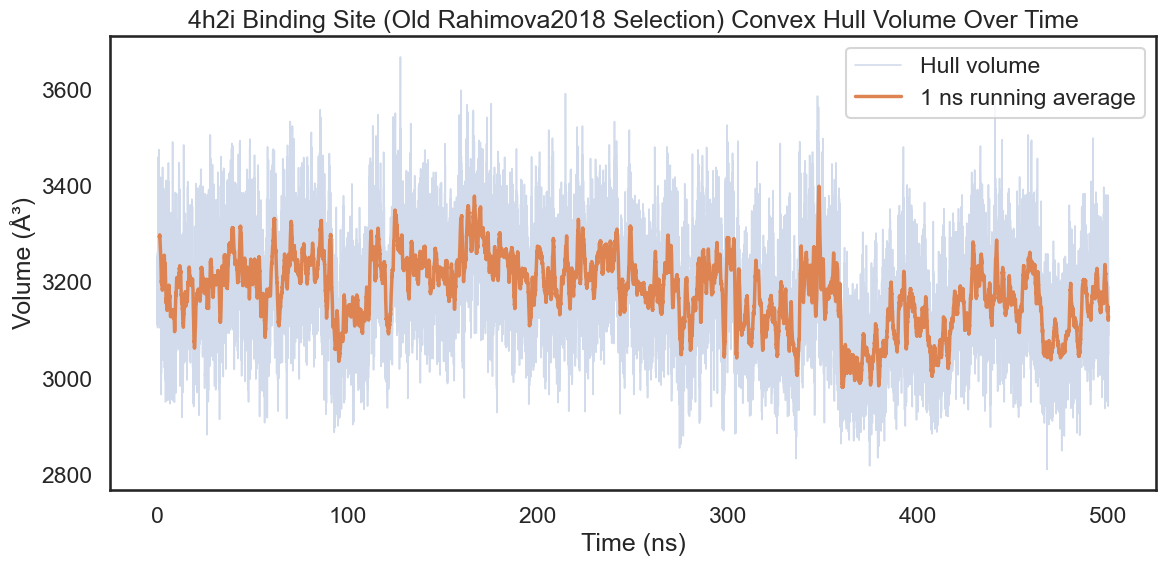

100%|██████████| 50006/50006 [01:19<00:00, 628.95it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i_noadn/unbiased/4h2i_noadn_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


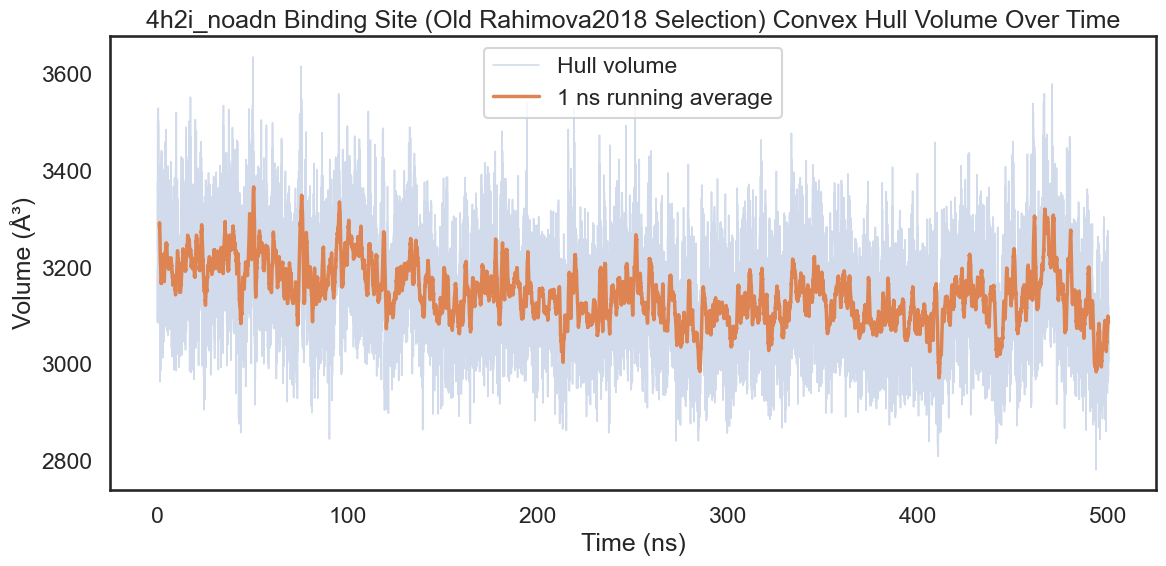

100%|██████████| 30003/30003 [00:47<00:00, 632.85it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/4h2g_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


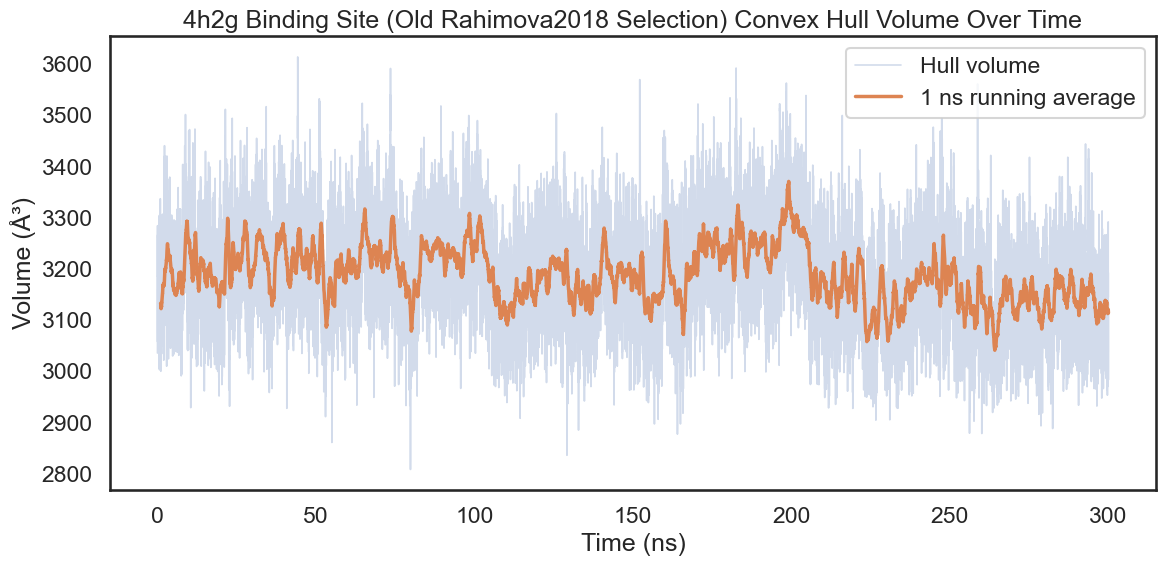

100%|██████████| 21892/21892 [00:33<00:00, 646.44it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g_noadn/unbiased/4h2g_noadn_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


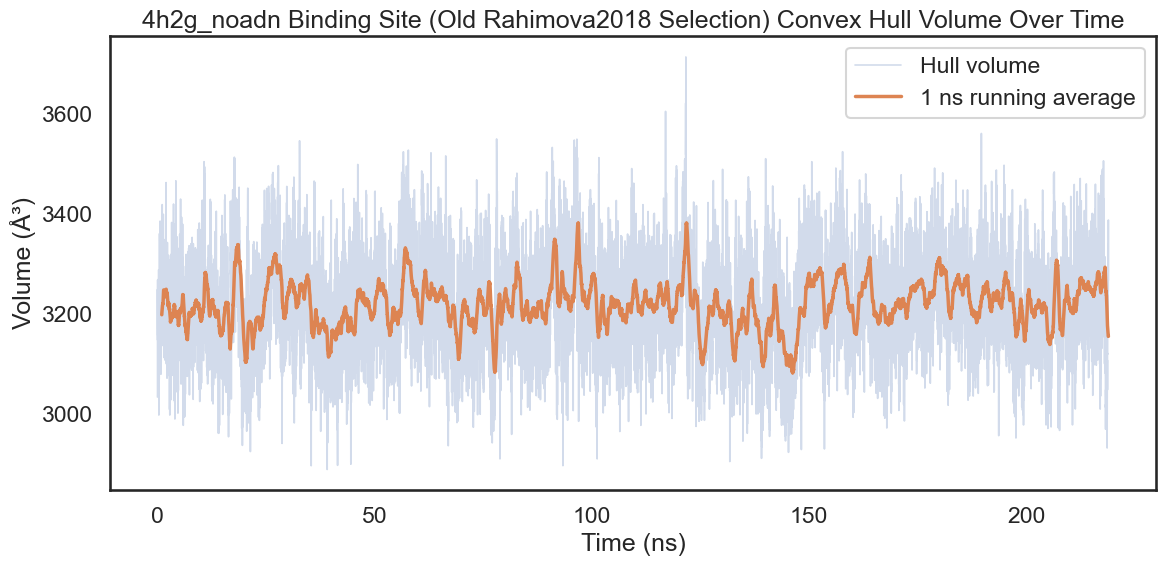

100%|██████████| 50006/50006 [01:19<00:00, 632.57it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6tve/unbiased/6tve_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


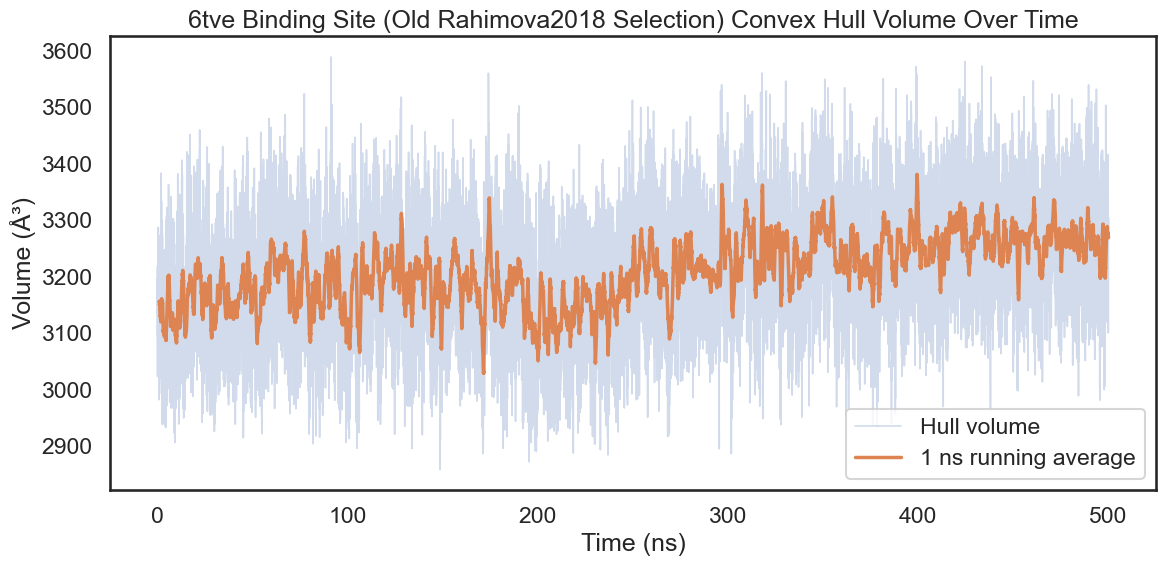

100%|██████████| 20002/20002 [00:31<00:00, 636.02it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6twa/unbiased/6twa_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


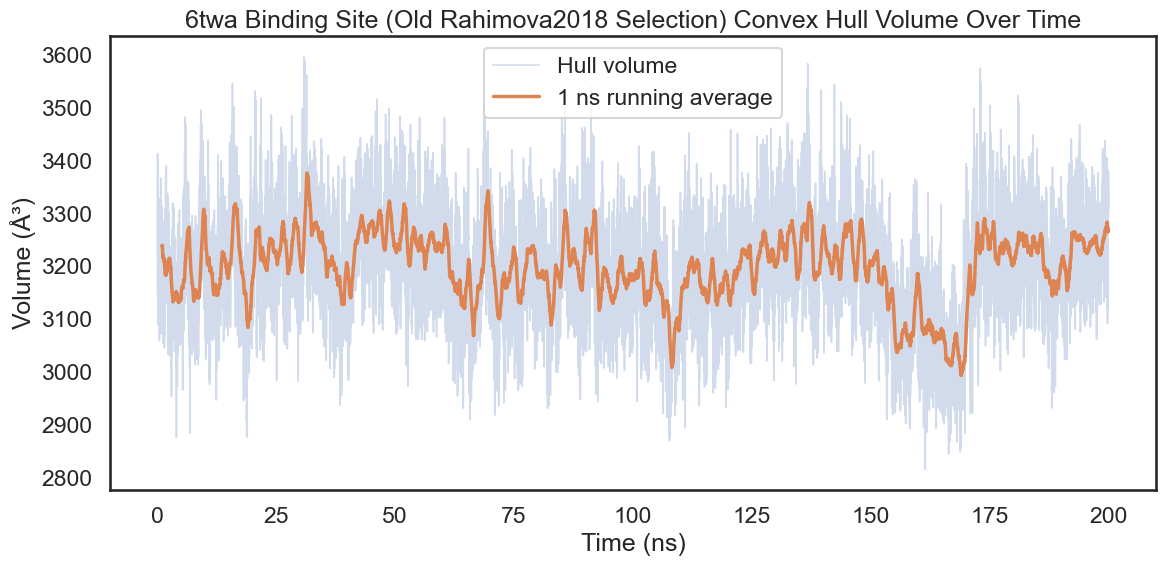

In [5]:
for name, traj in allosteric_bindingsite_trajectories_oldselection.items():
    traj.plot_volume_over_time(title=f"{name} Binding Site (Old Rahimova2018 Selection) Convex Hull Volume Over Time")

100%|██████████| 50005/50005 [01:20<00:00, 621.35it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i/unbiased/4h2i_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


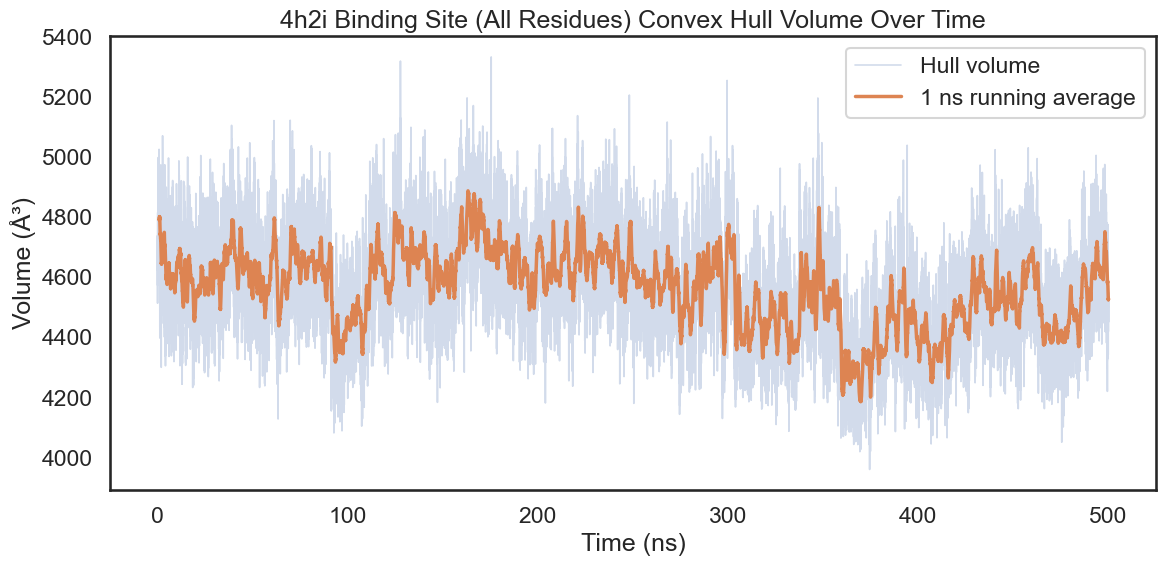

100%|██████████| 50006/50006 [01:21<00:00, 610.68it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i_noadn/unbiased/4h2i_noadn_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


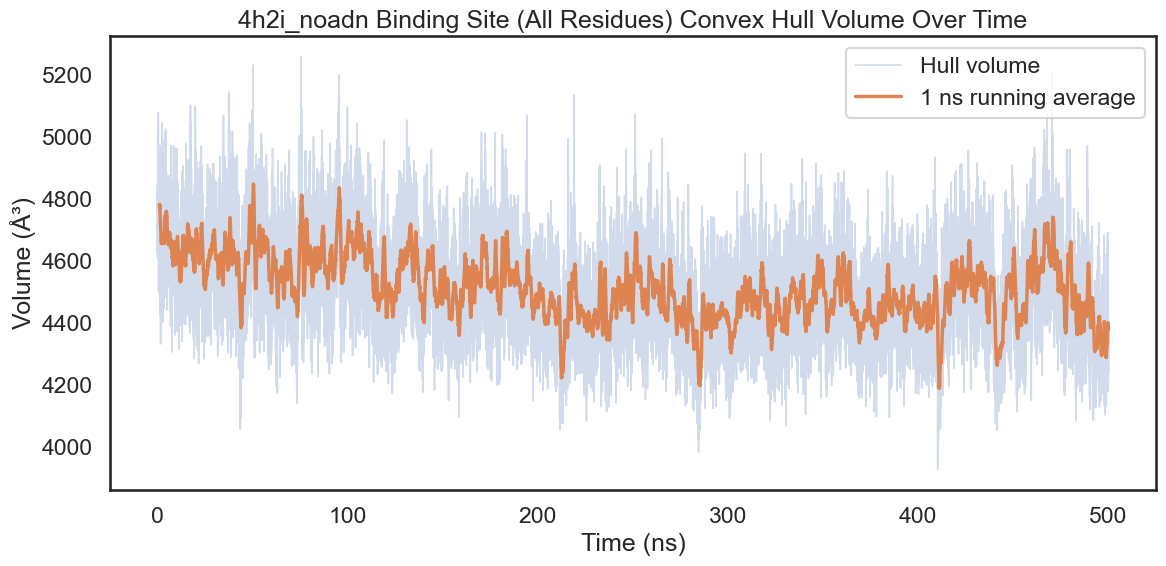

100%|██████████| 30003/30003 [00:47<00:00, 626.14it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/4h2g_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


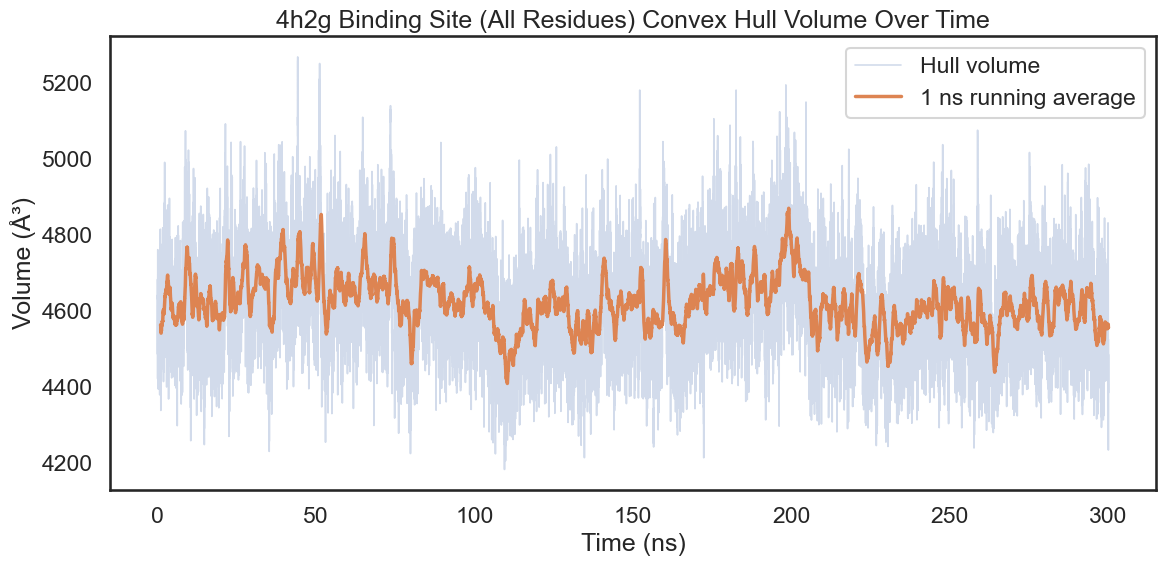

100%|██████████| 21892/21892 [00:35<00:00, 618.37it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g_noadn/unbiased/4h2g_noadn_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


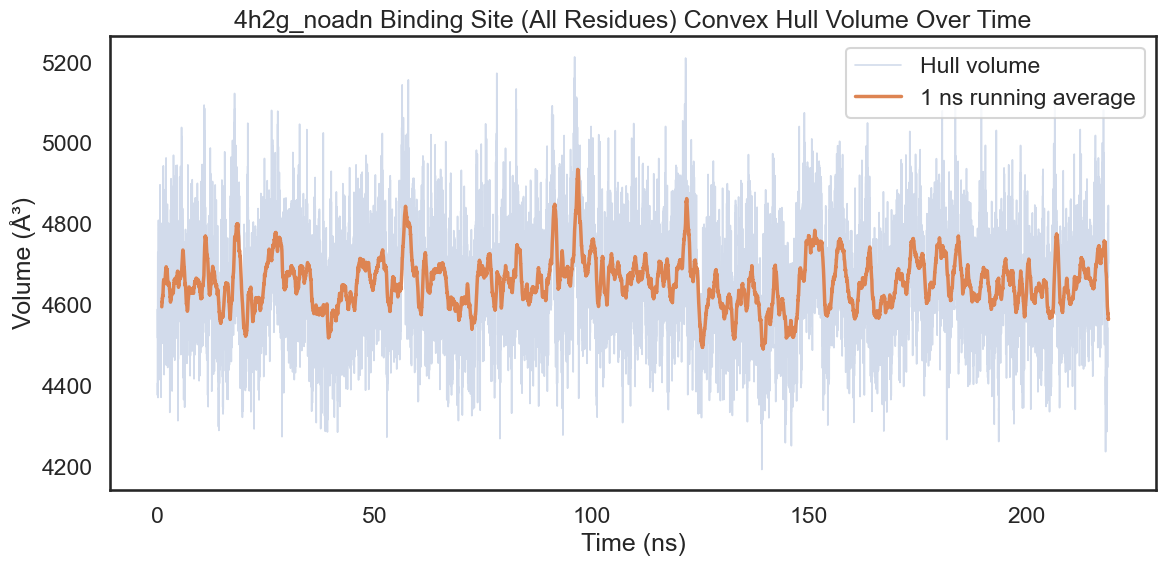

100%|██████████| 50006/50006 [01:19<00:00, 628.47it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6tve/unbiased/6tve_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


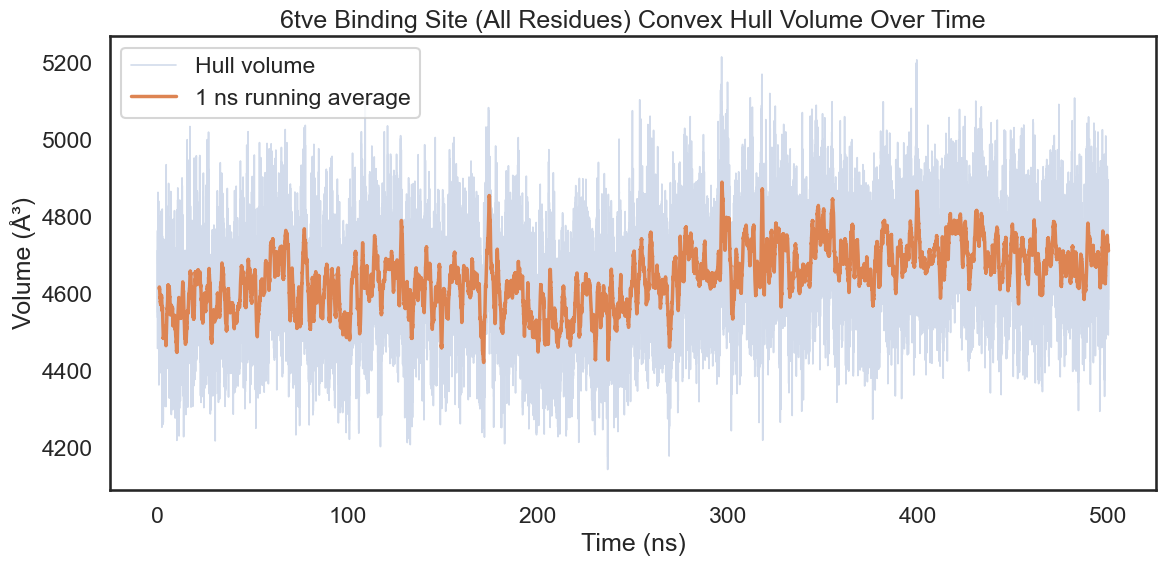

100%|██████████| 20002/20002 [00:31<00:00, 638.07it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6twa/unbiased/6twa_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


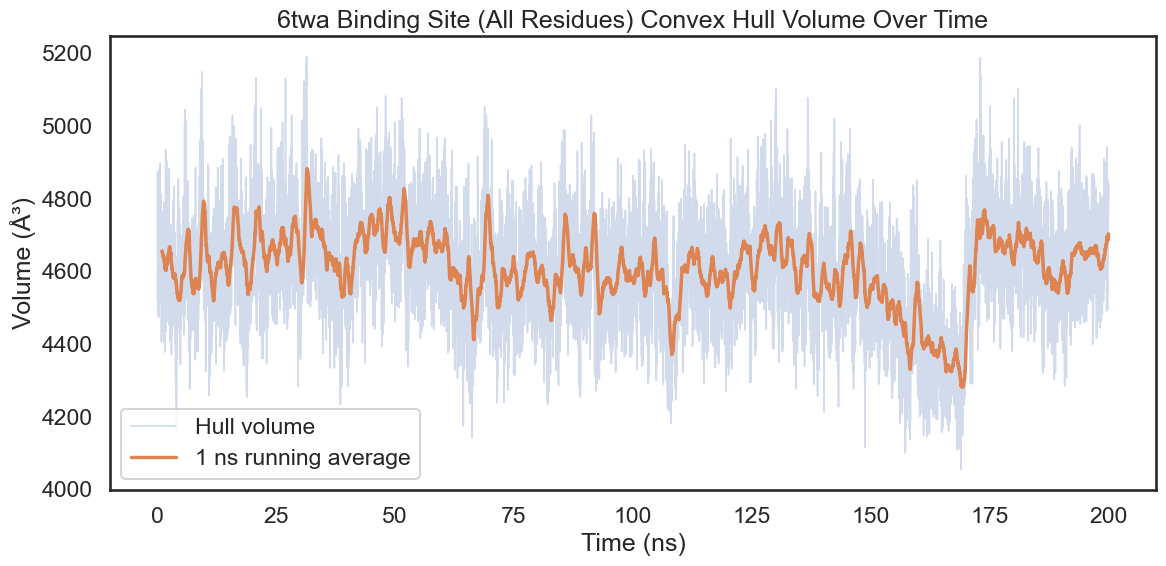

In [6]:
for name, traj in allosteric_bindingsite_trajectories.items():
    traj.plot_volume_over_time(title=f"{name} Binding Site (All Residues) Convex Hull Volume Over Time")

100%|██████████| 50005/50005 [01:27<00:00, 569.83it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i/unbiased/4h2i_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


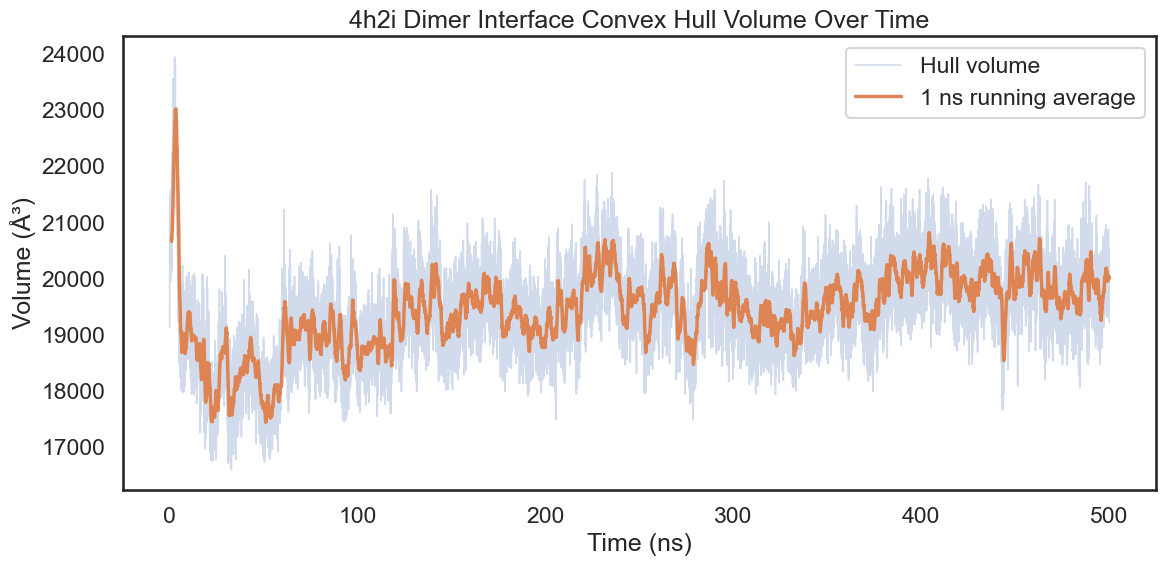

100%|██████████| 50006/50006 [01:30<00:00, 549.71it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i_noadn/unbiased/4h2i_noadn_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


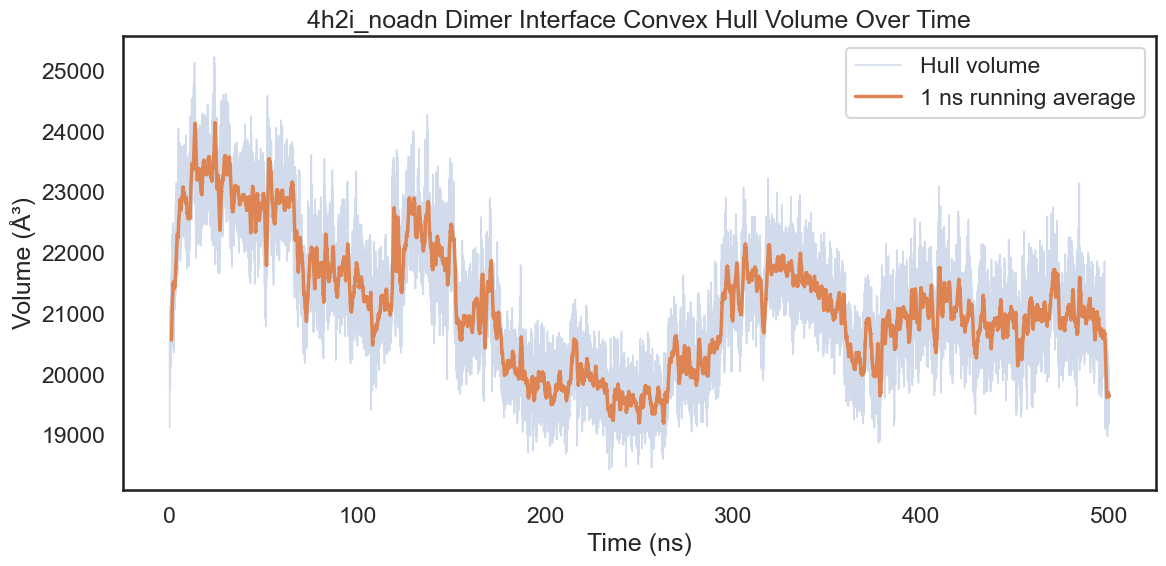

100%|██████████| 30003/30003 [00:58<00:00, 513.28it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/4h2g_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


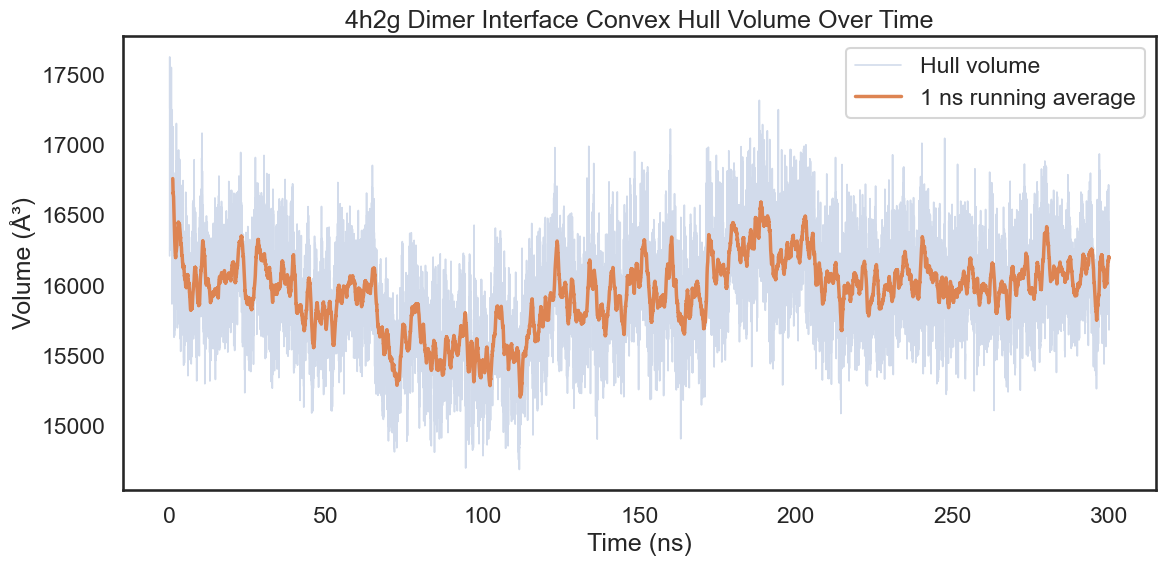

100%|██████████| 21892/21892 [00:37<00:00, 587.07it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g_noadn/unbiased/4h2g_noadn_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


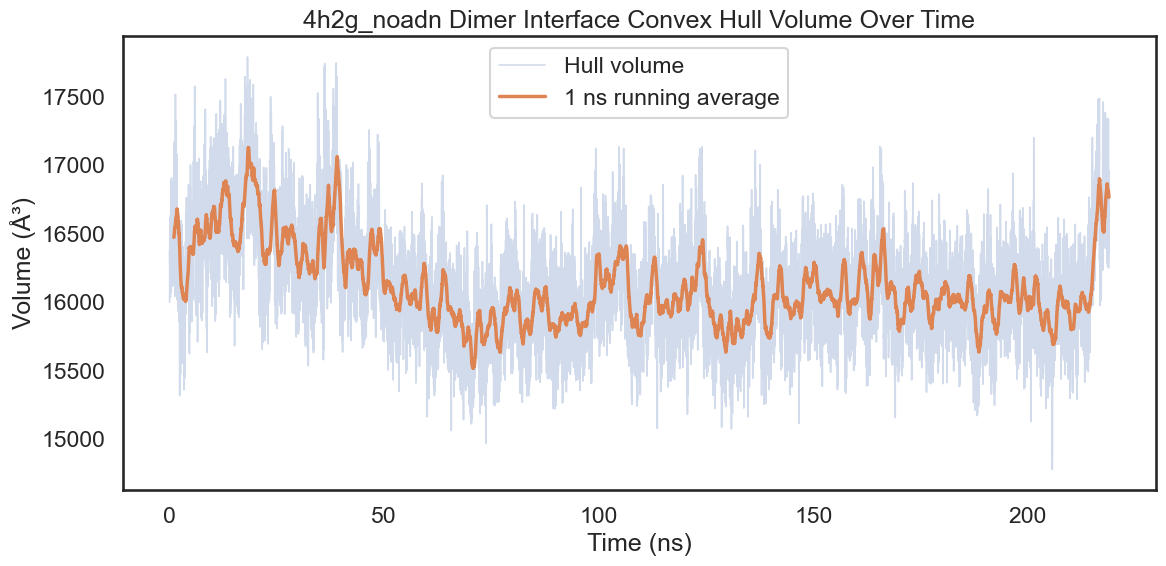

100%|██████████| 50006/50006 [01:30<00:00, 551.46it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6tve/unbiased/6tve_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


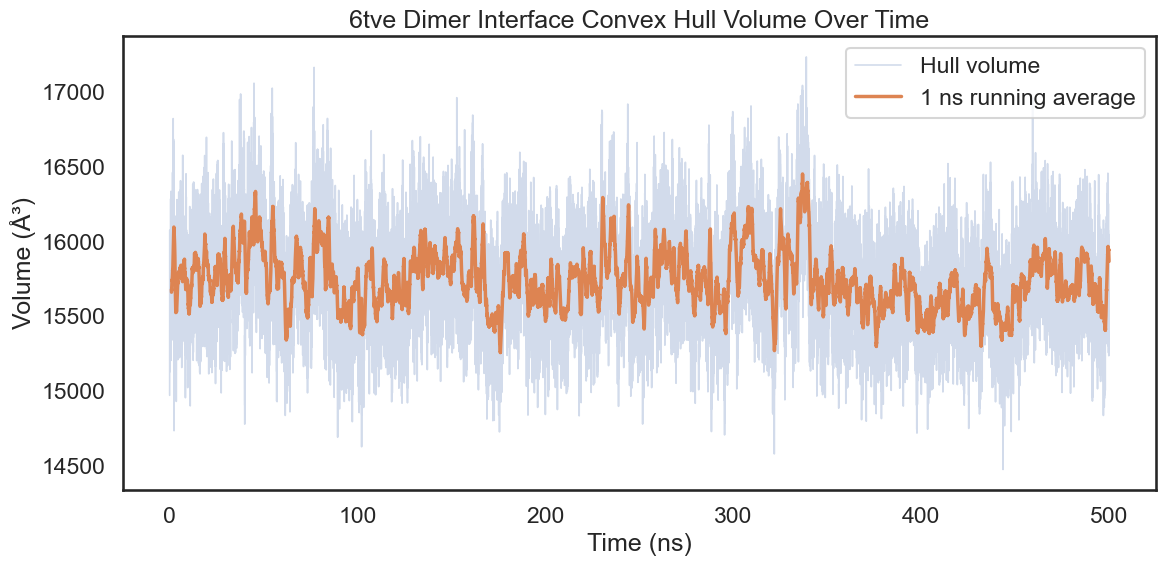

100%|██████████| 20002/20002 [00:35<00:00, 569.19it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6twa/unbiased/6twa_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


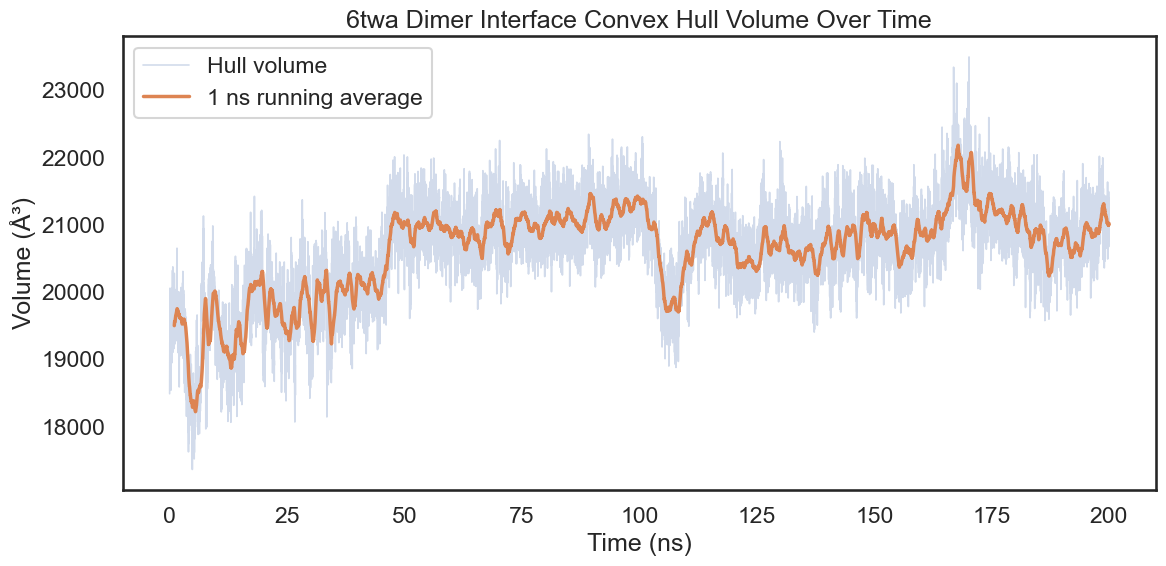

In [7]:
for name, traj in interface_trajectories.items():
    traj.plot_volume_over_time(title=f"{name} Dimer Interface Convex Hull Volume Over Time")

## Difference in dimer interface volume between open and closed structures
It can be observed that the closed (`6TWA`, `4H2I`) structures seem to have a larger dimer interface volume than the open-conformation protein (`6TVE`, `4H2G`).

In [8]:
allosteric_bindingsite_trajectories['4h2g'].write_system_frame_pdb(frame_index=5000)

Wrote system frame 5000 to PDB: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/frame_5000.pdb
Wrote hull PDB to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/hull_frame_5000.pdb
Wrote PyMol view script to /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/view_system_frame5000.pml


/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'elements' Using default value of ' '
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1336: UserWarning: Found missing chainIDs. Corresponding atoms will use value of 'X'
  warnings.warn(


## RMSD of allosteric binding site residues

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i/unbiased/4h2i_Binding_Site_RMSD_Over_Time_(All_atoms).png


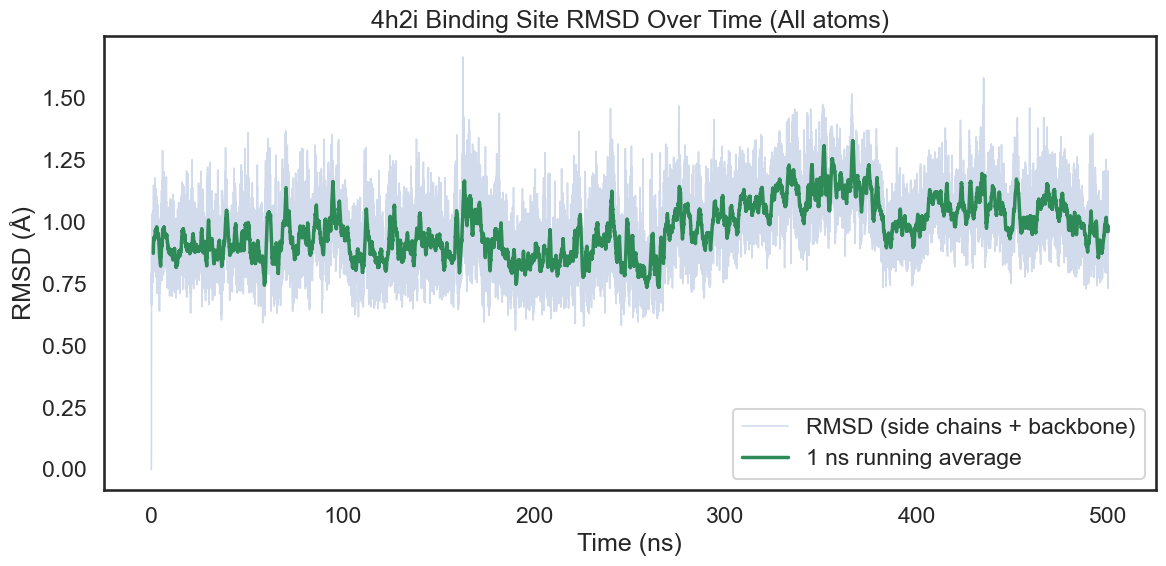

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i_noadn/unbiased/4h2i_noadn_Binding_Site_RMSD_Over_Time_(All_atoms).png


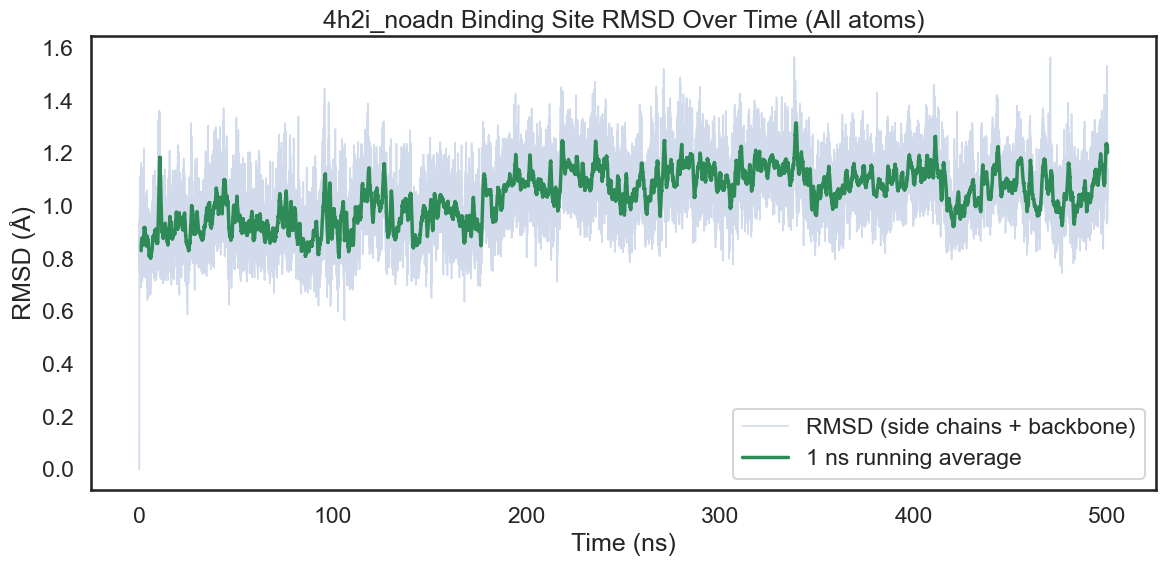

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/4h2g_Binding_Site_RMSD_Over_Time_(All_atoms).png


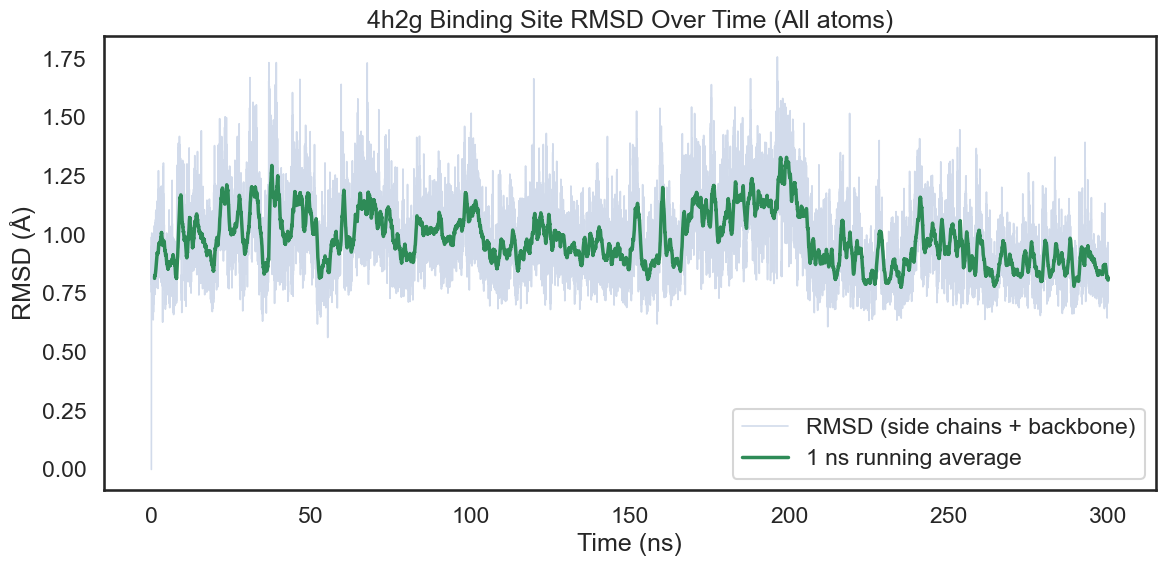

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g_noadn/unbiased/4h2g_noadn_Binding_Site_RMSD_Over_Time_(All_atoms).png


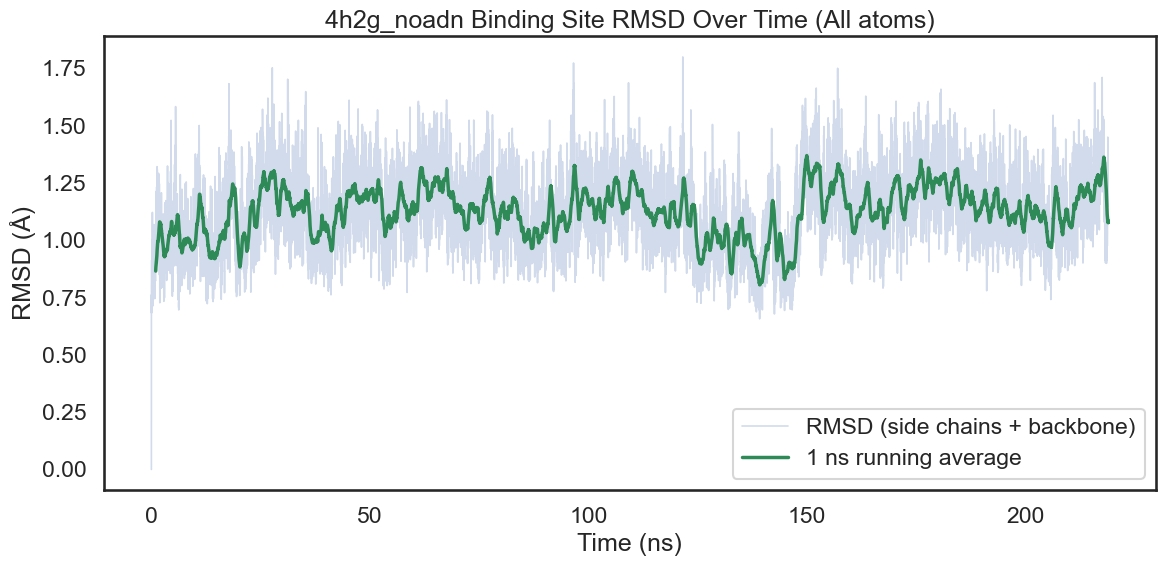

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6tve/unbiased/6tve_Binding_Site_RMSD_Over_Time_(All_atoms).png


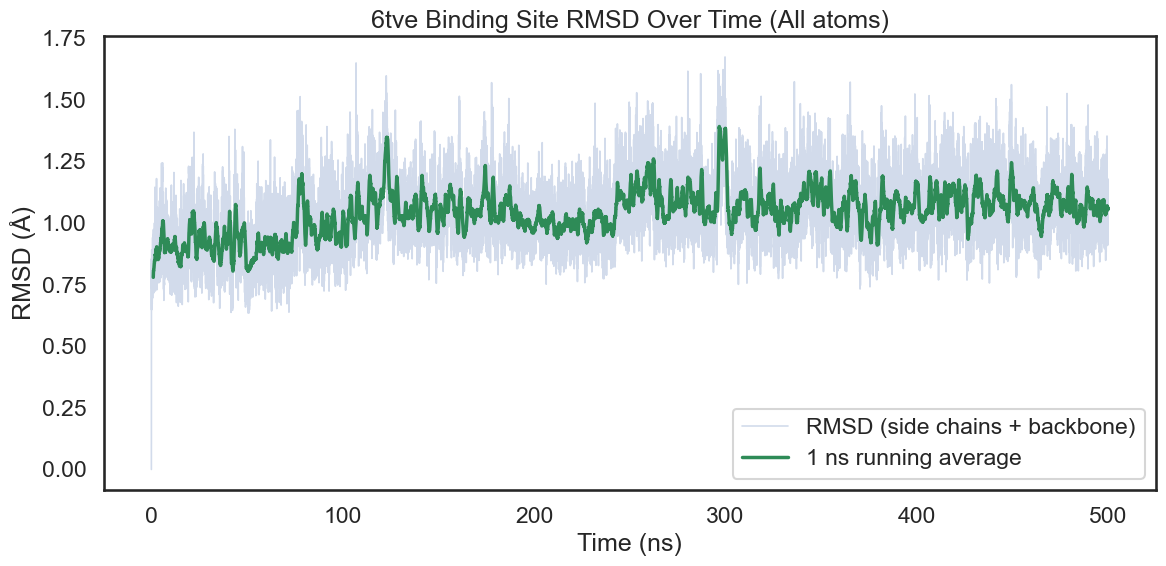

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6twa/unbiased/6twa_Binding_Site_RMSD_Over_Time_(All_atoms).png


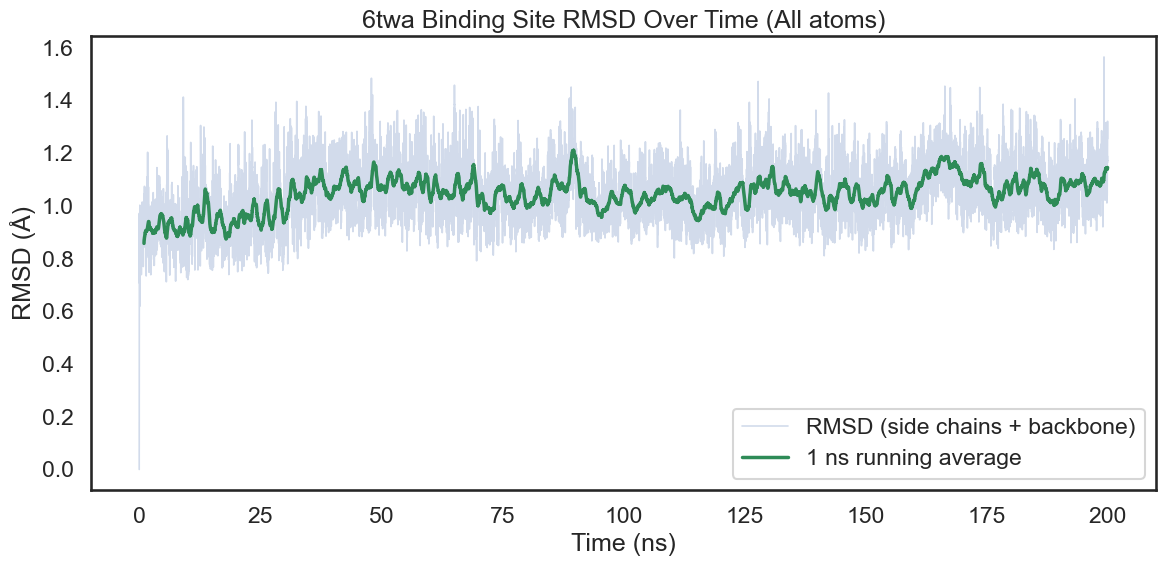

In [9]:
for name, traj in allosteric_bindingsite_trajectories.items():
    traj.plot_rmsd_over_time(title=f"{name} Binding Site RMSD Over Time (All atoms)", only_sidechains=False)

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i/unbiased/4h2i_Binding_Site_RMSD_Over_Time_(Only_Sidechains).png


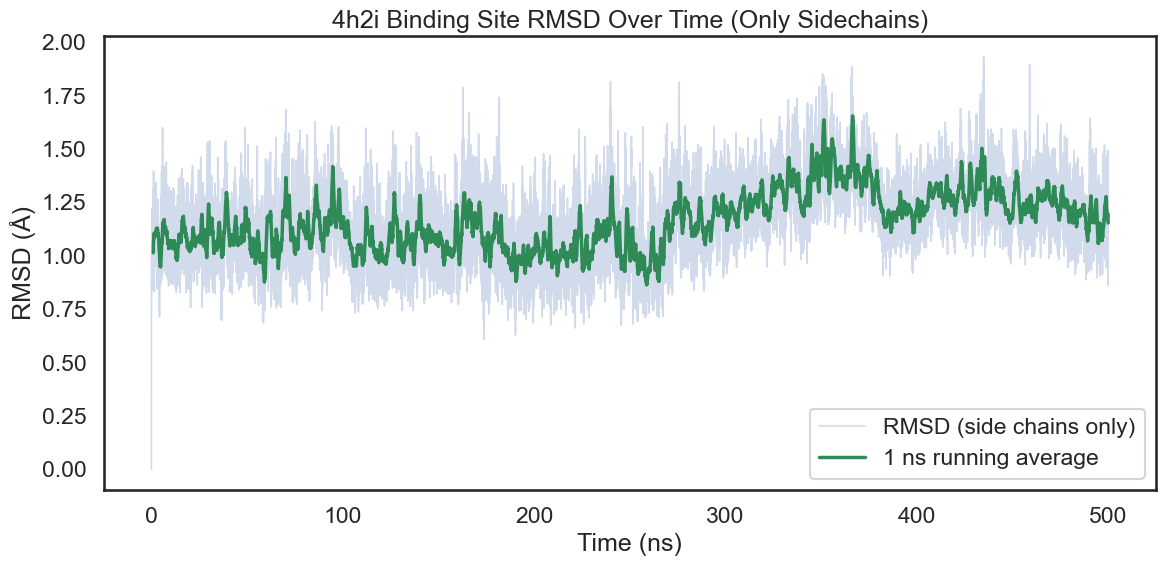

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i_noadn/unbiased/4h2i_noadn_Binding_Site_RMSD_Over_Time_(Only_Sidechains).png


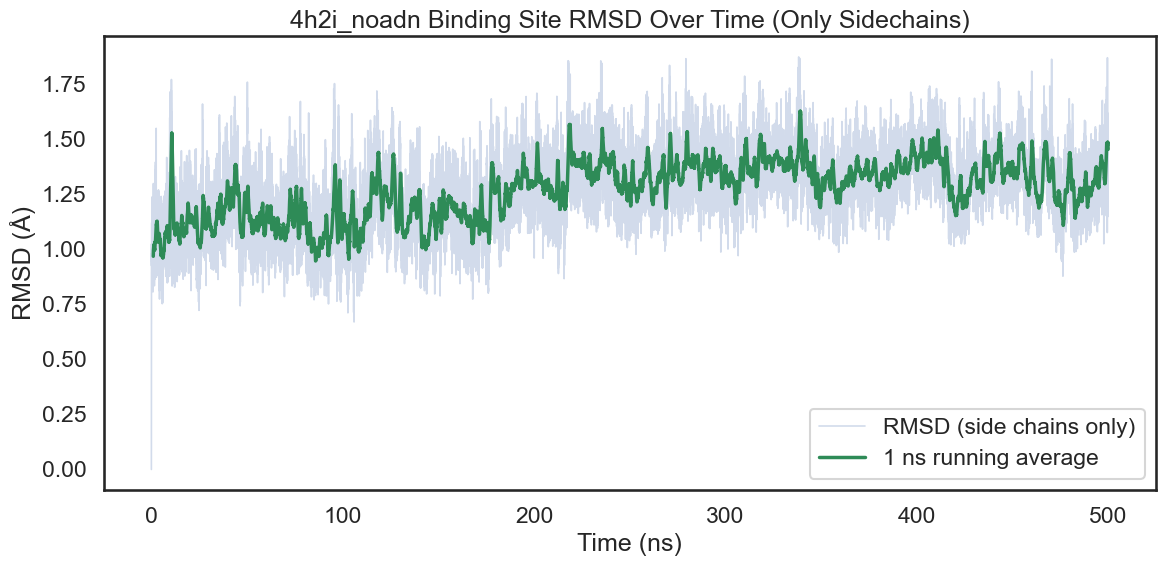

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/4h2g_Binding_Site_RMSD_Over_Time_(Only_Sidechains).png


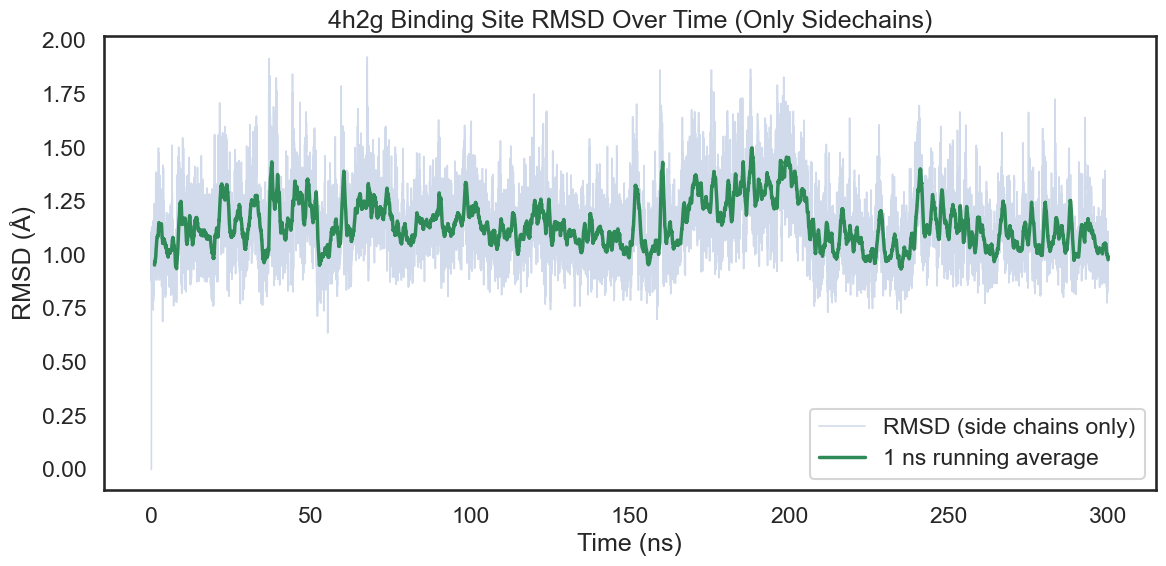

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g_noadn/unbiased/4h2g_noadn_Binding_Site_RMSD_Over_Time_(Only_Sidechains).png


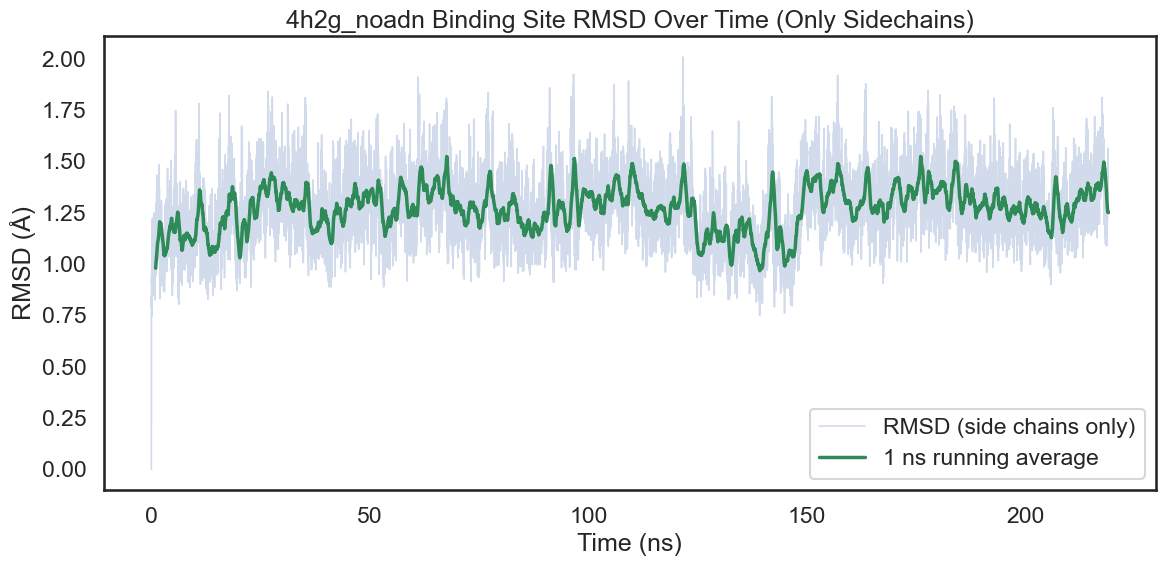

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6tve/unbiased/6tve_Binding_Site_RMSD_Over_Time_(Only_Sidechains).png


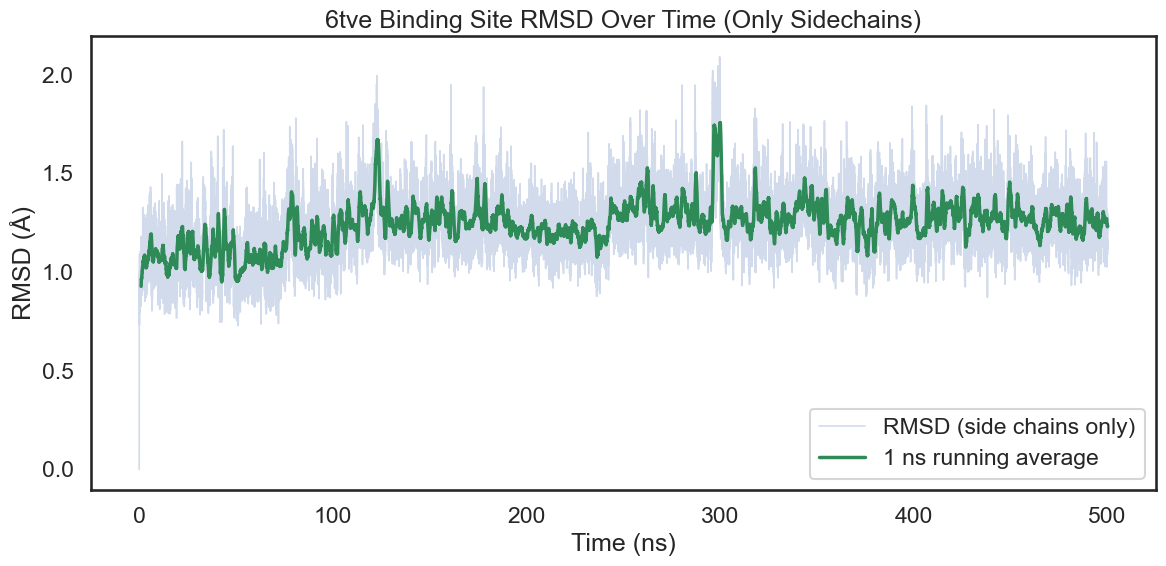

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6twa/unbiased/6twa_Binding_Site_RMSD_Over_Time_(Only_Sidechains).png


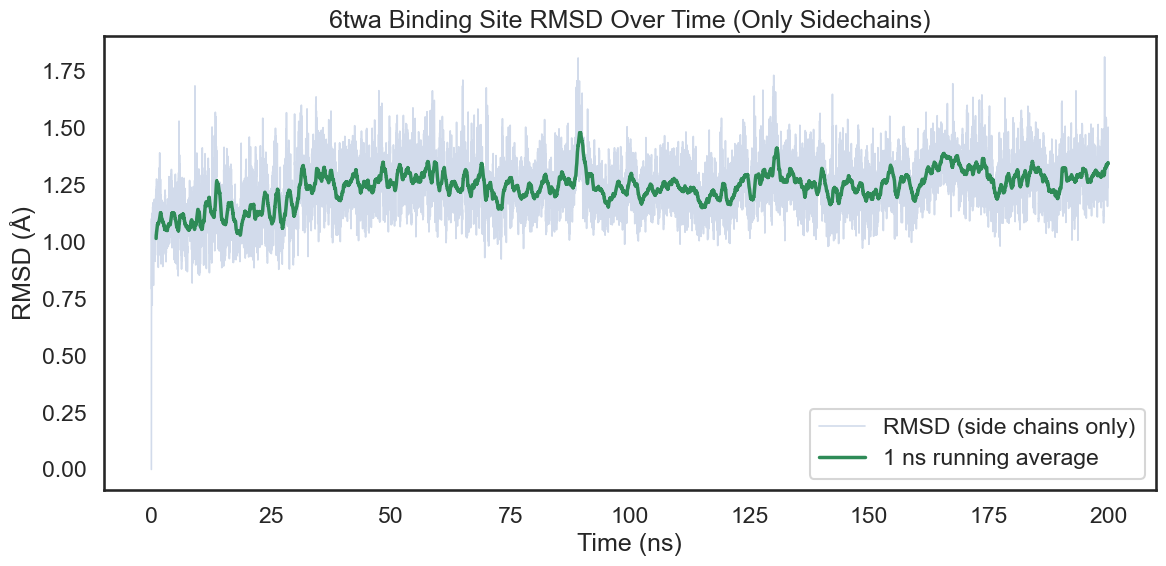

In [10]:
for name, traj in allosteric_bindingsite_trajectories.items():
    traj.plot_rmsd_over_time(title=f"{name} Binding Site RMSD Over Time (Only Sidechains)", only_sidechains=True)

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i/unbiased/4h2i_Dimer_Interface_RMSD_Over_Time_(All_atoms).png


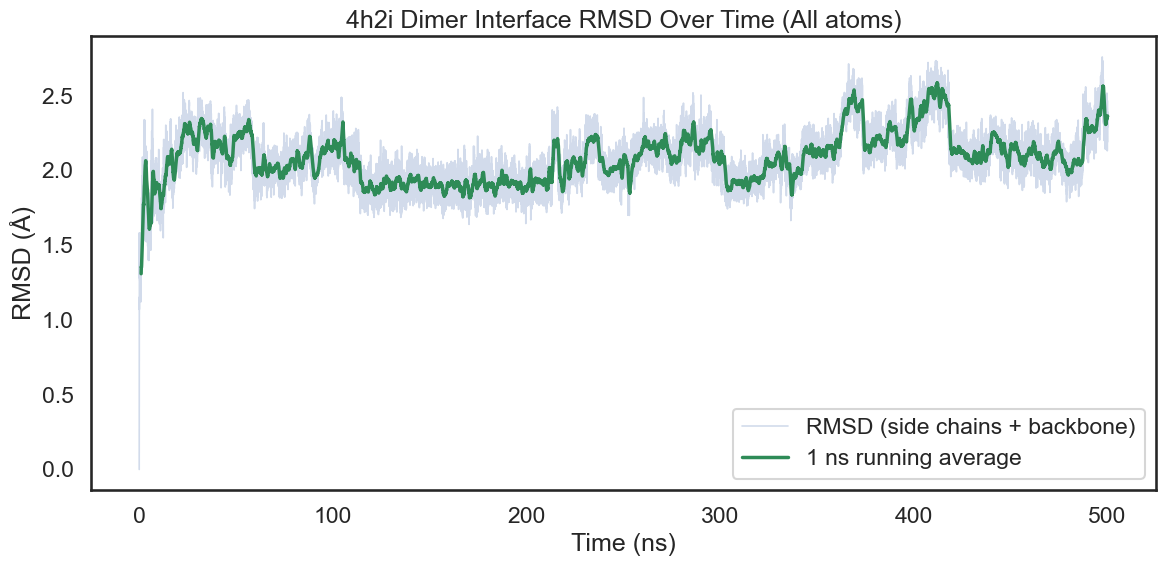

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i_noadn/unbiased/4h2i_noadn_Dimer_Interface_RMSD_Over_Time_(All_atoms).png


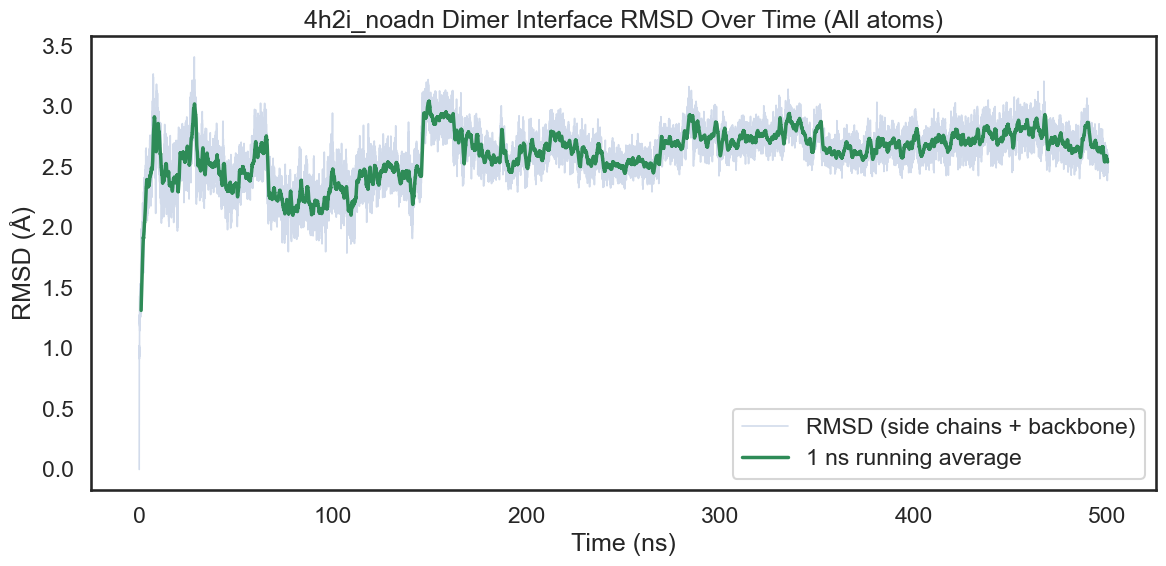

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/4h2g_Dimer_Interface_RMSD_Over_Time_(All_atoms).png


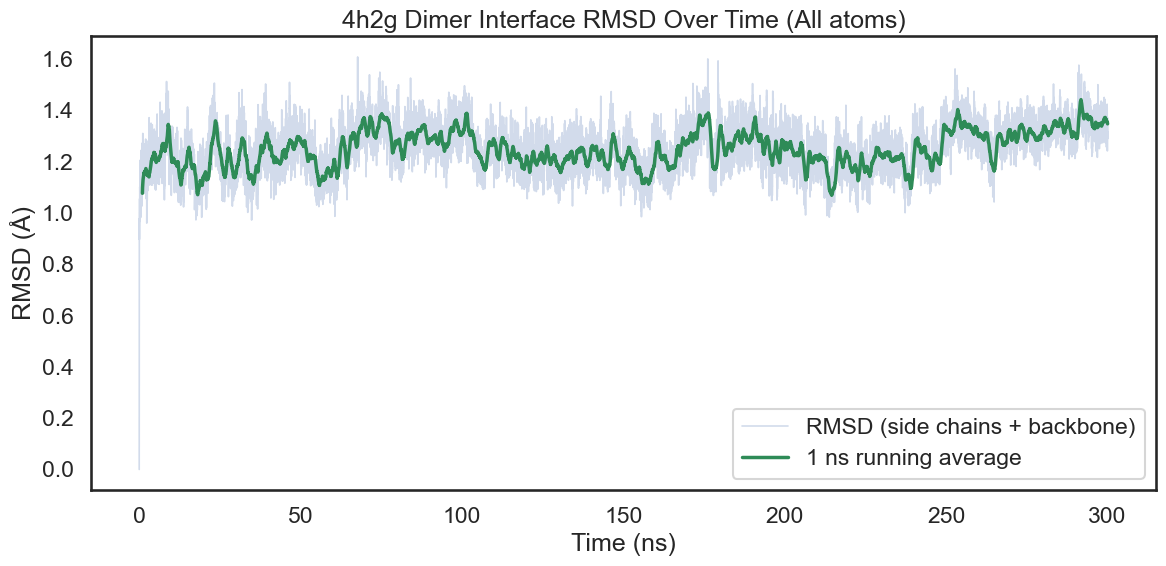

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g_noadn/unbiased/4h2g_noadn_Dimer_Interface_RMSD_Over_Time_(All_atoms).png


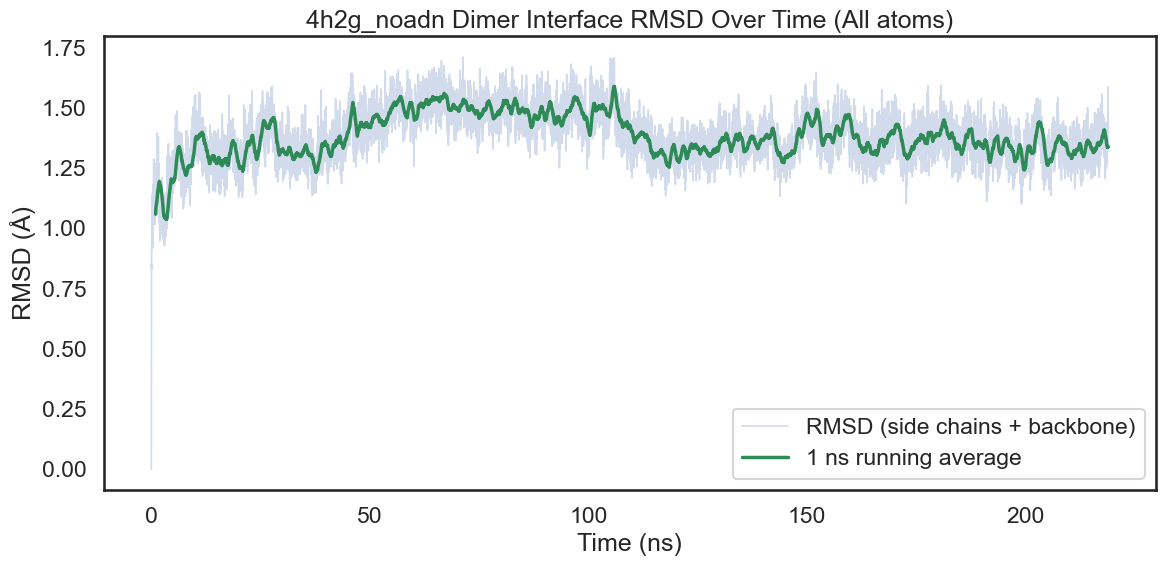

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6tve/unbiased/6tve_Dimer_Interface_RMSD_Over_Time_(All_atoms).png


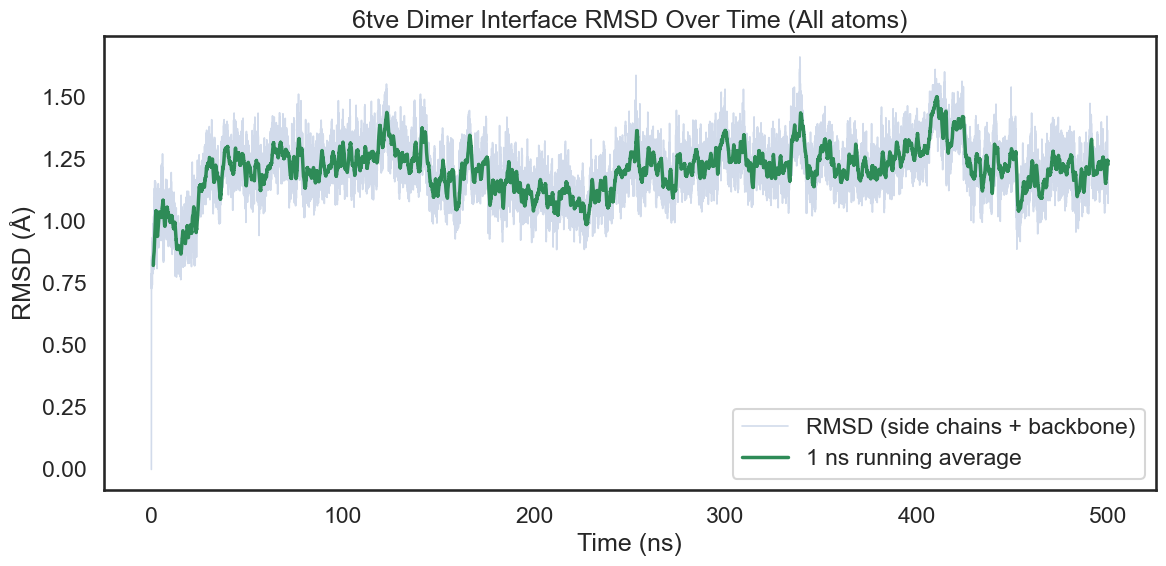

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6twa/unbiased/6twa_Dimer_Interface_RMSD_Over_Time_(All_atoms).png


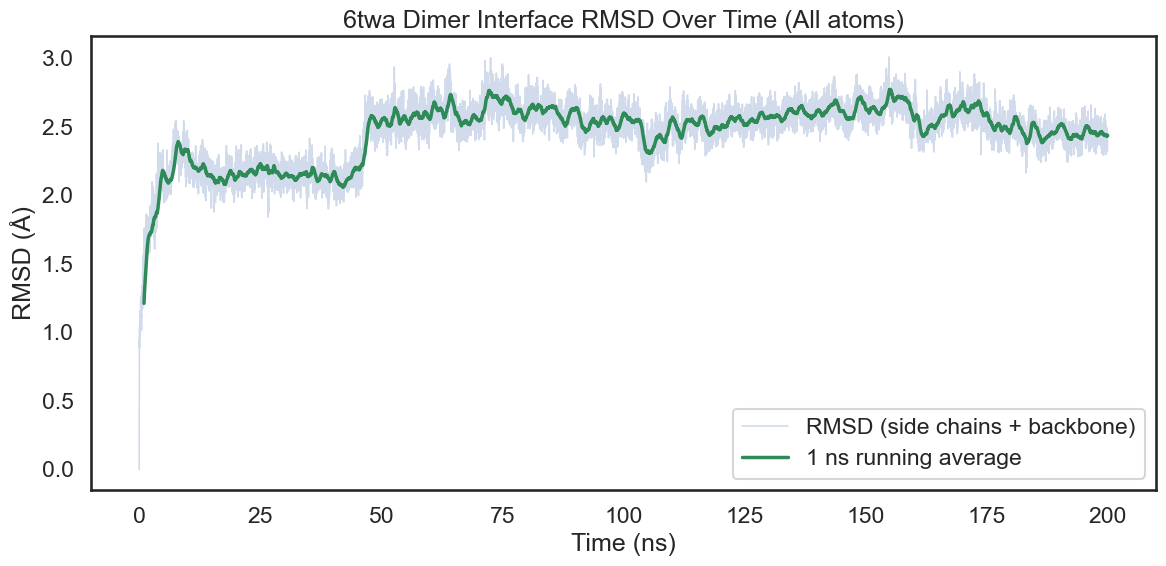

In [11]:
for name, traj in interface_trajectories.items():
    traj.plot_rmsd_over_time(title=f"{name} Dimer Interface RMSD Over Time (All atoms)", only_sidechains=False)
    

In [12]:
# RMSF = rms.RMSF(allosteric_bindingsite_trajectories['4h2g'].residue_atoms)
# RMSF.run()
# RMSF.rmsf

# R = rms.RMSD(allosteric_bindingsite_trajectories['4h2g'].residue_atoms,
#              allosteric_bindingsite_trajectories['4h2g'].residue_atoms,
#              ref_frame=0)
# R.run()

In [21]:
allosteric_bindingsite_trajectories['4h2g'].write_system_frame_pdb(frame_index=5000)

Wrote system frame 5000 to PDB: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/frame_5000.pdb
Wrote hull PDB to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/hull_frame_5000.pdb
Wrote PyMol view script to /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/view_system_frame5000.pml


/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'elements' Using default value of ' '
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1336: UserWarning: Found missing chainIDs. Corresponding atoms will use value of 'X'
  warnings.warn(


# Autocorrelation time of allosteric binding site volumes and RMSD's 
Grossfield et al. (2019, https://livecomsjournal.org/index.php/livecoms/article/view/v1i1e5067/913) discusses the implementation of autocorrelation time analysis to estimate the number of independent samples in a (time series) MD trajectory. 

Here, I implement this analysis to calculate the autocorrelation time to 1. estimate standard uncertainty of the allosteric binding pocket volumes, and 2. find out the number of samples with statistically independent volumes for docking (check that my MD simulation time is long enough to sample independent conformers)

**To-do: autocorrelation time of binding site RMSD**

In [13]:
def autocorrelation_time(series: np.ndarray[float], dt: float) -> float:
    n = len(series)
    series = series - np.mean(series)

    var = np.var(series)
    acf = np.zeros(n)

    for lag in range(n):
        x1 = series[:n - lag]
        x2 = series[lag:]
        acf[lag] = np.mean(x1 * x2) / var

    zeros = np.where(acf < 0)[0]
    cutoff = zeros[0] if len(zeros) > 0 else n

    tau_int = dt * (1 + 2*np.sum(acf[1:cutoff]))
    return tau_int

def effective_sample_size(series: np.ndarray[float], dt: float) -> float:
    tau_int = autocorrelation_time(series, dt)
    n = len(series)
    n_eff = n * dt / (2 * tau_int)
    return n_eff

def bootstrap_confidence_interval(series: np.ndarray[float], dt: float, n_bootstrap: int = 1000, confidence_level: float = 0.95) -> tuple[float, float]:
    n_eff = effective_sample_size(series, dt)
    n = len(series)
    indices = np.random.choice(n, size=(n_bootstrap, int(n_eff)), replace=True)
    bootstrap_means = np.array([np.mean(series[idx]) for idx in indices])
    lower_bound = np.percentile(bootstrap_means, (1 - confidence_level) / 2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 + confidence_level) / 2 * 100)
    return lower_bound, upper_bound


### Hull Volumes


In [14]:
for name, traj in allosteric_bindingsite_trajectories.items():
    volumes = np.array([hull.volume for hull in traj.hulls])
    print(f"{name} - Allosteric Binding Pocket Volume Autocorrelation time: {autocorrelation_time(volumes, traj.universe.trajectory.dt)}")
    print(f"{name} - Effective sample size: {effective_sample_size(volumes, traj.universe.trajectory.dt)}")
    print(f"{name} - Mean and SEM: {np.mean(volumes)}, {np.std(volumes) / np.sqrt(effective_sample_size(volumes, traj.universe.trajectory.dt))}")
    print(f"{name} - 95% CI: {bootstrap_confidence_interval(volumes, traj.universe.trajectory.dt)}")
    print("\n")

4h2i - Allosteric Binding Pocket Volume Autocorrelation time: 37965.106710942244
4h2i - Effective sample size: 6.5856525020101735
4h2i - Mean and SEM: 4563.293745983524, 64.65373131961618
4h2i - 95% CI: (np.float64(4418.215547293721), np.float64(4691.636096183459))


4h2i_noadn - Allosteric Binding Pocket Volume Autocorrelation time: 30608.026836615518
4h2i_noadn - Effective sample size: 8.16877224182567
4h2i_noadn - Mean and SEM: 4511.47085902167, 51.831205564644975
4h2i_noadn - 95% CI: (np.float64(4409.453486091503), np.float64(4613.74517750827))


4h2g - Allosteric Binding Pocket Volume Autocorrelation time: 3904.9555397148024
4h2g - Effective sample size: 38.41657055356802
4h2g - Mean and SEM: 4621.524375695344, 20.53488343862613
4h2g - 95% CI: (np.float64(4581.988793041042), np.float64(4662.2758879679795))


4h2g_noadn - Allosteric Binding Pocket Volume Autocorrelation time: 537.0375715333303
4h2g_noadn - Effective sample size: 203.82186610794056
4h2g_noadn - Mean and SEM: 4656.27

In [15]:
for name, traj in interface_trajectories.items():
    volumes = np.array([hull.volume for hull in traj.hulls])
    print(f"{name} - Dimer Interface Volume Autocorrelation time: {autocorrelation_time(volumes, traj.universe.trajectory.dt)}")
    print(f"{name} - Effective sample size: {effective_sample_size(volumes, traj.universe.trajectory.dt)}")
    print(f"{name} - Mean and SEM: {np.mean(volumes)}, {np.std(volumes) / np.sqrt(effective_sample_size(volumes, traj.universe.trajectory.dt))}")
    print(f"{name} - 95% CI: {bootstrap_confidence_interval(volumes, traj.universe.trajectory.dt)}")
    print("\n")

4h2i - Dimer Interface Volume Autocorrelation time: 38614.52447216974
4h2i - Effective sample size: 6.4748952218794775
4h2i - Mean and SEM: 19442.998282147575, 307.84405182994954
4h2i - 95% CI: (np.float64(18818.836414500132), np.float64(20045.588496877135))


4h2i_noadn - Dimer Interface Volume Autocorrelation time: 68587.73946760819
4h2i_noadn - Effective sample size: 3.6454037112286115
4h2i_noadn - Mean and SEM: 21152.16045918052, 571.8569747902596
4h2i_noadn - 95% CI: (np.float64(20034.674526705698), np.float64(22542.84461278606))


4h2g - Dimer Interface Volume Autocorrelation time: 20181.77524987323
4h2g - Effective sample size: 7.433191487995701
4h2g - Mean and SEM: 15954.734456109698, 126.72968083637672
4h2g - 95% CI: (np.float64(15711.3533217943), np.float64(16198.468713309907))


4h2g_noadn - Dimer Interface Volume Autocorrelation time: 13572.239981214252
4h2g_noadn - Effective sample size: 8.064991493777512
4h2g_noadn - Mean and SEM: 16118.155852149404, 132.43235584738608
4h

### RMSD

In [18]:
for name, traj in allosteric_bindingsite_trajectories.items():
    rmsd = traj.rmsd
    print(f"{name} - Allosteric Binding Pocket RMSD Autocorrelation time: {autocorrelation_time(rmsd, traj.universe.trajectory.dt)}")
    print(f"{name} - Effective sample size: {effective_sample_size(rmsd, traj.universe.trajectory.dt)}")
    print(f"{name} - Mean and SEM: {np.mean(rmsd)}, {np.std(rmsd) / np.sqrt(effective_sample_size(rmsd, traj.universe.trajectory.dt))}")
    print(f"{name} - 95% CI: {bootstrap_confidence_interval(rmsd, traj.universe.trajectory.dt)}")
    print("\n")

4h2i - Allosteric Binding Pocket RMSD Autocorrelation time: 47454.93956207217
4h2i - Effective sample size: 5.268682297507964
4h2i - Mean and SEM: 0.971132143017476, 0.059982806528759924
4h2i - 95% CI: (np.float64(0.8569144519460989), np.float64(1.0962135943990277))


4h2i_noadn - Allosteric Binding Pocket RMSD Autocorrelation time: 58826.568257858555
4h2i_noadn - Effective sample size: 4.250290428366078
4h2i_noadn - Mean and SEM: 1.0387174487308872, 0.061451276764045173
4h2i_noadn - 95% CI: (np.float64(0.911699303224338), np.float64(1.1520640517365068))


4h2g - Allosteric Binding Pocket RMSD Autocorrelation time: 8357.226571946896
4h2g - Effective sample size: 17.950333009226117
4h2g - Mean and SEM: 0.9807386195211365, 0.03660521769458208
4h2g - 95% CI: (np.float64(0.9109778284402996), np.float64(1.0575012422015222))


4h2g_noadn - Allosteric Binding Pocket RMSD Autocorrelation time: 3310.5428099939745
4h2g_noadn - Effective sample size: 33.064064198039844
4h2g_noadn - Mean and SEM: 

In [20]:
for name, traj in interface_trajectories.items():
    rmsd = traj.rmsd
    print(f"{name} - Dimer Interface RMSD Autocorrelation time: {autocorrelation_time(rmsd, traj.universe.trajectory.dt)}")
    print(f"{name} - Effective sample size: {effective_sample_size(rmsd, traj.universe.trajectory.dt)}")
    print(f"{name} - Mean and SEM: {np.mean(rmsd)}, {np.std(rmsd) / np.sqrt(effective_sample_size(rmsd, traj.universe.trajectory.dt))}")
    print(f"{name} - 95% CI: {bootstrap_confidence_interval(rmsd, traj.universe.trajectory.dt)}")
    print("\n")

4h2i - Dimer Interface RMSD Autocorrelation time: 37689.94041321997
4h2i - Effective sample size: 6.633732960540905
4h2i - Mean and SEM: 2.084226439343131, 0.06946405711391539
4h2i - 95% CI: (np.float64(1.9450861611427477), np.float64(2.2344343068495665))


4h2i_noadn - Dimer Interface RMSD Autocorrelation time: 63368.898213600914
4h2i_noadn - Effective sample size: 3.9456264358141526
4h2i_noadn - Mean and SEM: 2.6088844188169564, 0.1082805884050023
4h2i_noadn - 95% CI: (np.float64(2.357133161103471), np.float64(2.8252211989232423))


4h2g - Dimer Interface RMSD Autocorrelation time: 10102.392666083717
4h2g - Effective sample size: 14.849452496895932
4h2g - Mean and SEM: 1.2489898287876997, 0.022566622316228892
4h2g - 95% CI: (np.float64(1.20725989299758), np.float64(1.2915513738736273))


4h2g_noadn - Dimer Interface RMSD Autocorrelation time: 18830.76855508918
4h2g_noadn - Effective sample size: 5.812827005959748
4h2g_noadn - Mean and SEM: 1.382614765750663, 0.04345434941609699
4h2g_

## Investigation of highly flexible residues

Starting 4h2i
RMSF done in 63.6s


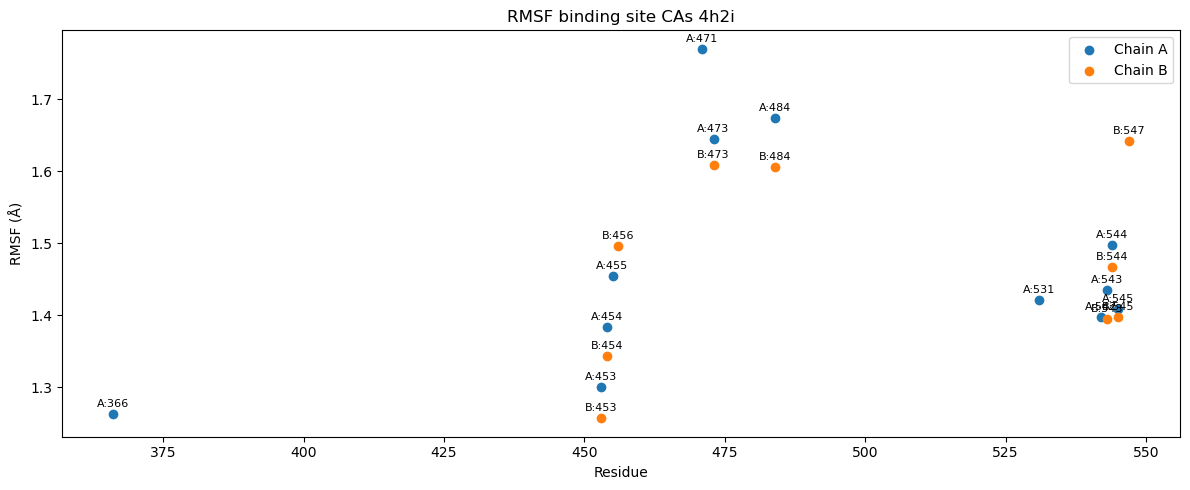

Finished 4h2i
Starting 4h2i_noadn
RMSF done in 62.7s


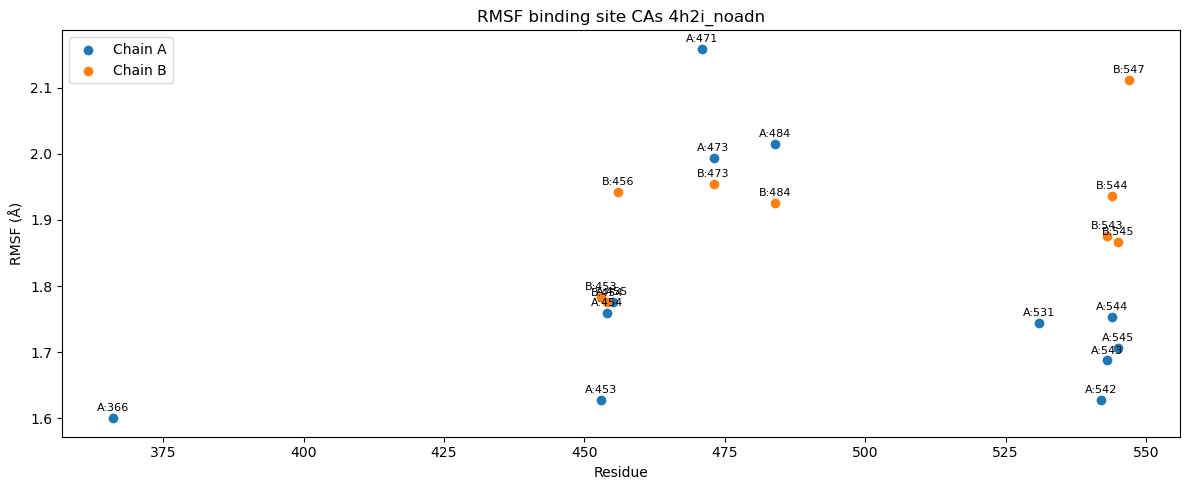

Finished 4h2i_noadn
Starting 4h2g
RMSF done in 36.7s


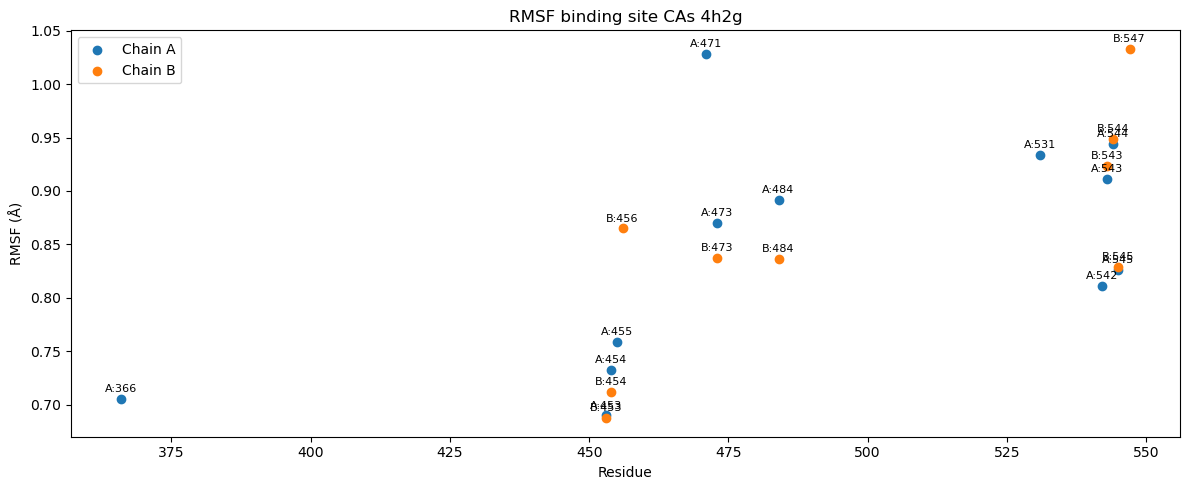

Finished 4h2g
Starting 4h2g_noadn
RMSF done in 26.5s


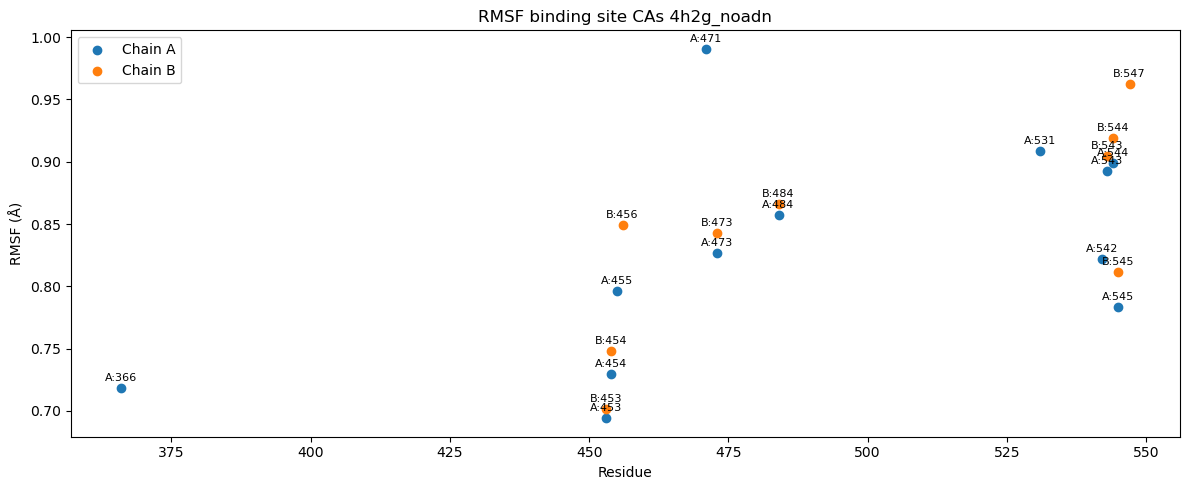

Finished 4h2g_noadn
Starting 6tve
RMSF done in 62.5s


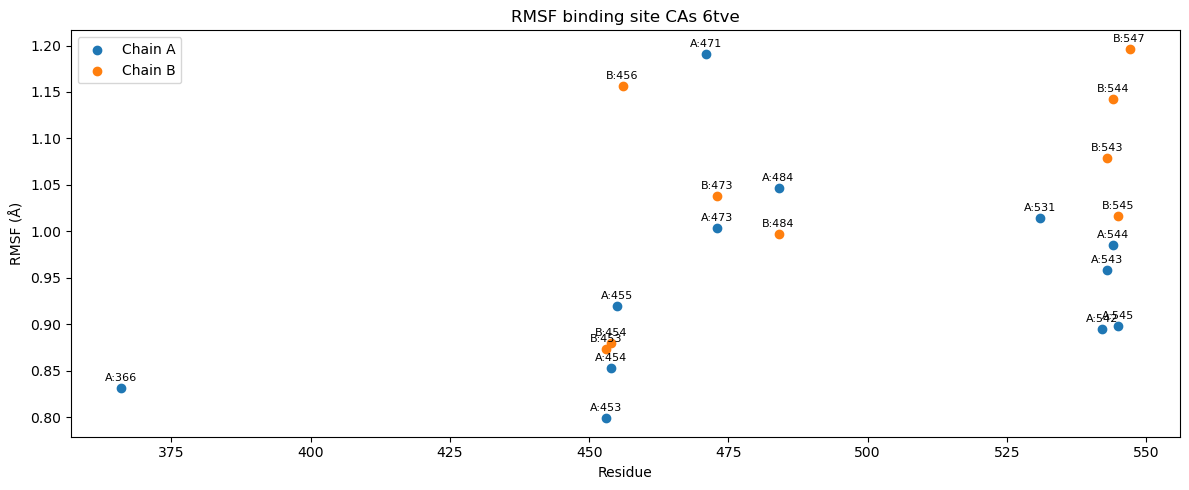

Finished 6tve
Starting 6twa
RMSF done in 23.7s


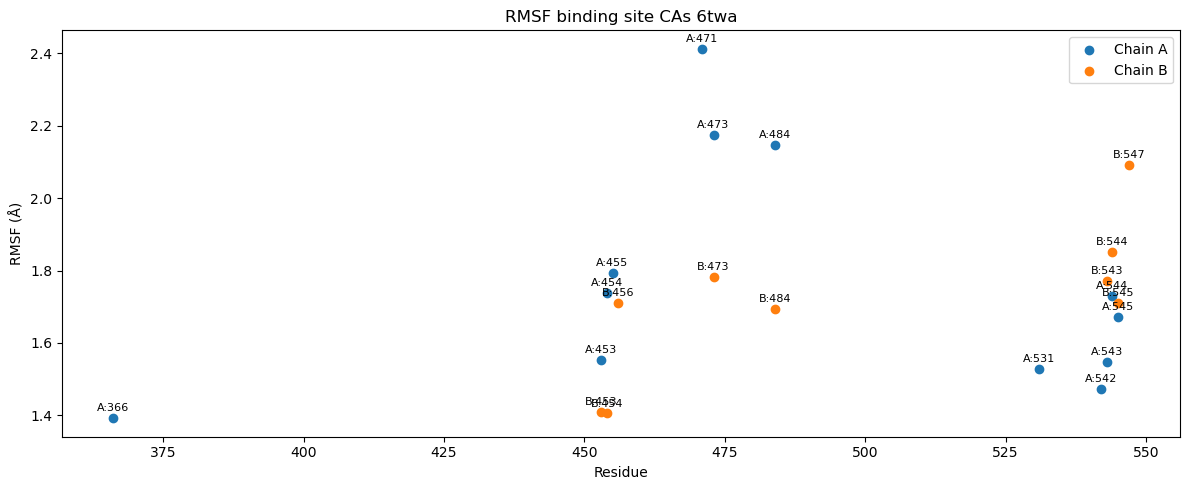

Finished 6twa


In [7]:
import time

rmsf_dfs = {}

for name, traj in allosteric_bindingsite_trajectories.items():

    t0 = time.time()
    print(f"Starting {name}")

    sel = traj.residue_atoms.select_atoms('protein and name CA')

    bindingsite_RMSF = rms.RMSF(sel)
    bindingsite_RMSF.run()

    print(f"RMSF done in {time.time() - t0:.1f}s")

    rmsf_df = pd.DataFrame({
        "chain": sel.segids,
        "resid": sel.resids,
        "rmsf": bindingsite_RMSF.results.rmsf
    })

    rmsf_dfs[name] = rmsf_df

    fig, ax = plt.subplots(figsize=(12, 5))

    for chain, subdf in rmsf_df.groupby("chain"):

        # scatter only, no connecting lines
        ax.scatter(
            subdf["resid"],
            subdf["rmsf"],
            label=f"Chain {chain}"
        )

        # annotate every point
        for _, row in subdf.iterrows():
            ax.annotate(
                f"{row['chain']}:{row['resid']}",
                (row["resid"], row["rmsf"]),
                textcoords="offset points",
                xytext=(0, 5),
                ha='center',
                fontsize=8
            )

    ax.set_xlabel("Residue")
    ax.set_ylabel("RMSF (Å)")
    ax.set_title(f"RMSF binding site CAs {name}")
    ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    print(f"Finished {name}")

Key flexible residues are several lysines (K471-A, K547-B), tyrosines (Y484-A+B, Y531-A), aspartate 473-A, histidine H456-B, and glycine G544-B.

The Glu 543-A,B seem to have moderately low RMSF values. This puts more confidence in centering the docking box around this residue, which was done by the Montpellier-group. Still, other flexible residues can lead to great variability between ensemble docking structures. 

## Dihedral analysis / clustering

Here follows a analysis of the dihedral angles of the flexible residues above (excluding glycine G544-B) to identify if there are possible rotamers that are visited regularly and should be included in the ensemble docking structures.

- $\chi_1$ angle: N-CA-CB-CG (rotation of CA-CB bond)
- $\chi_2$ angle: CA-CB-CG-CD (rotation of CB-CG bond)

In [133]:
dihedral_inspection_sel = [
    (471, "A"), (547, "B"),
    (484, "A"), (484, "B"), (531, "A"), 
    (473, "A"), (456, "B"),
]

In [134]:
janin_results = {}

for name, traj in allosteric_bindingsite_trajectories.items():
    print(f"doing trajectory {name}")
    janin_results[name] = {}

    for residue in dihedral_inspection_sel:
        residue_key = f"{residue[0]}-{residue[1]}"
        janin_results[name][residue_key] = {}

        janin = Janin(
            traj.universe.select_atoms(f"protein and resid {residue[0]} and segid {residue[1]}")
        )
        print(f"started Janin for {residue}")
        janin.run()

        angles = janin.results.angles[:, 0, :]
        chi1 = list(angles[:, 0])
        chi2 = list(angles[:, 1])

        janin_results[name][residue_key]["chi1"] = chi1
        janin_results[name][residue_key]["chi2"] = chi2



doing trajectory 4h2i
started Janin for (471, 'A')
started Janin for (547, 'B')
started Janin for (484, 'A')
started Janin for (484, 'B')
started Janin for (531, 'A')
started Janin for (473, 'A')
started Janin for (456, 'B')
doing trajectory 4h2i_noadn
started Janin for (471, 'A')
started Janin for (547, 'B')
started Janin for (484, 'A')
started Janin for (484, 'B')
started Janin for (531, 'A')
started Janin for (473, 'A')
started Janin for (456, 'B')
doing trajectory 4h2g
started Janin for (471, 'A')
started Janin for (547, 'B')
started Janin for (484, 'A')
started Janin for (484, 'B')
started Janin for (531, 'A')
started Janin for (473, 'A')
started Janin for (456, 'B')
doing trajectory 4h2g_noadn
started Janin for (471, 'A')
started Janin for (547, 'B')
started Janin for (484, 'A')
started Janin for (484, 'B')
started Janin for (531, 'A')
started Janin for (473, 'A')
started Janin for (456, 'B')
doing trajectory 6tve
started Janin for (471, 'A')
started Janin for (547, 'B')
started 

### Saving / Loading Janin dihedral angle-results

In [5]:
# Saving / Loading Janin results as .JSON

# with open("./data/janin_results.json", "w") as f:
#    json.dump(janin_results, f)

# with open("./data/janin_results.json", "w") as f:
#     json.dump(
#         {k: vars(v) for k, v in janin_results.items()},
#         f,
#         indent=2
#     )

janin_results = json.load(open("./data/janin_results.json"))



In [9]:
for key in janin_results.keys():
    print(key)

4h2i
4h2i_noadn
4h2g
4h2g_noadn
6tve
6twa


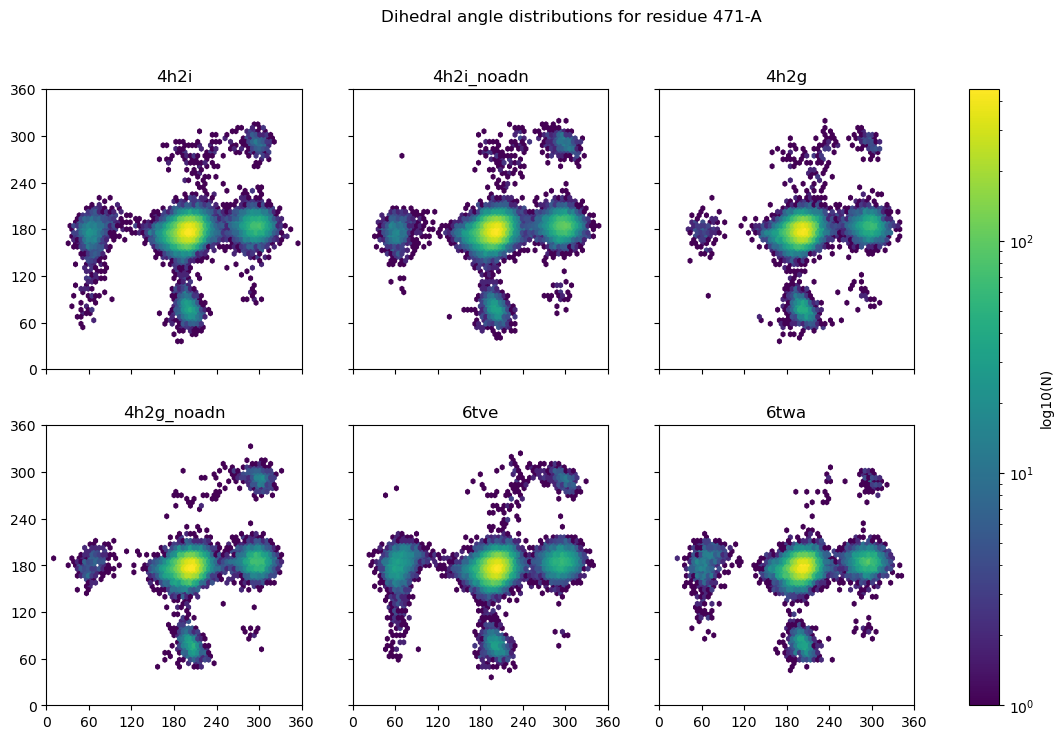

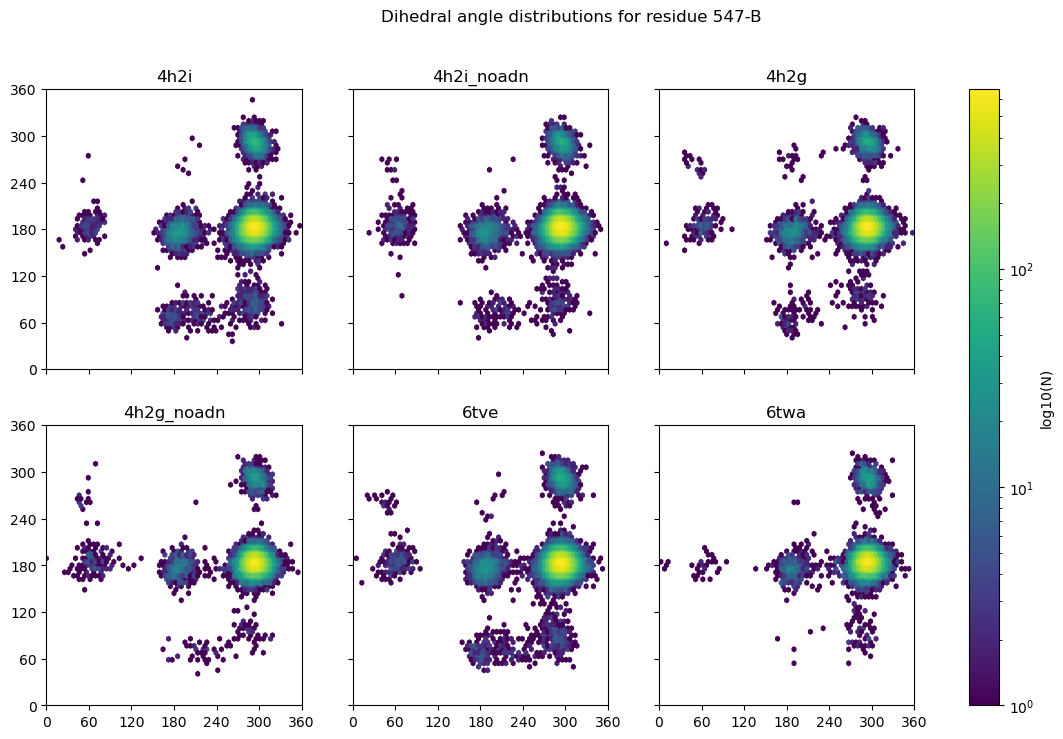

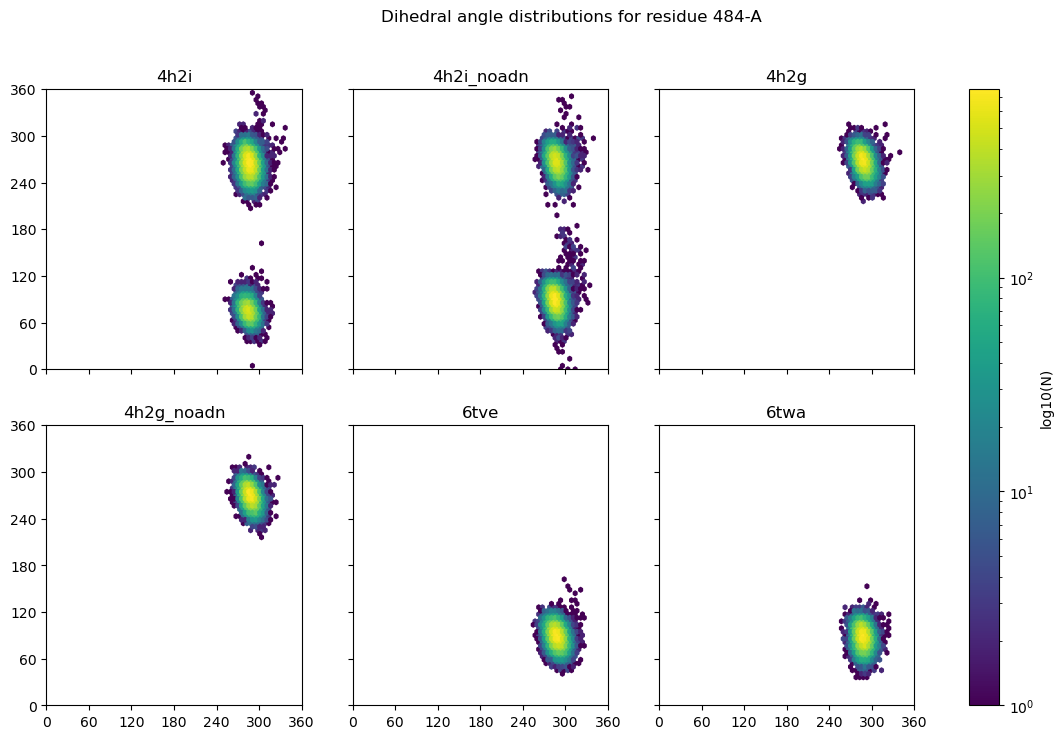

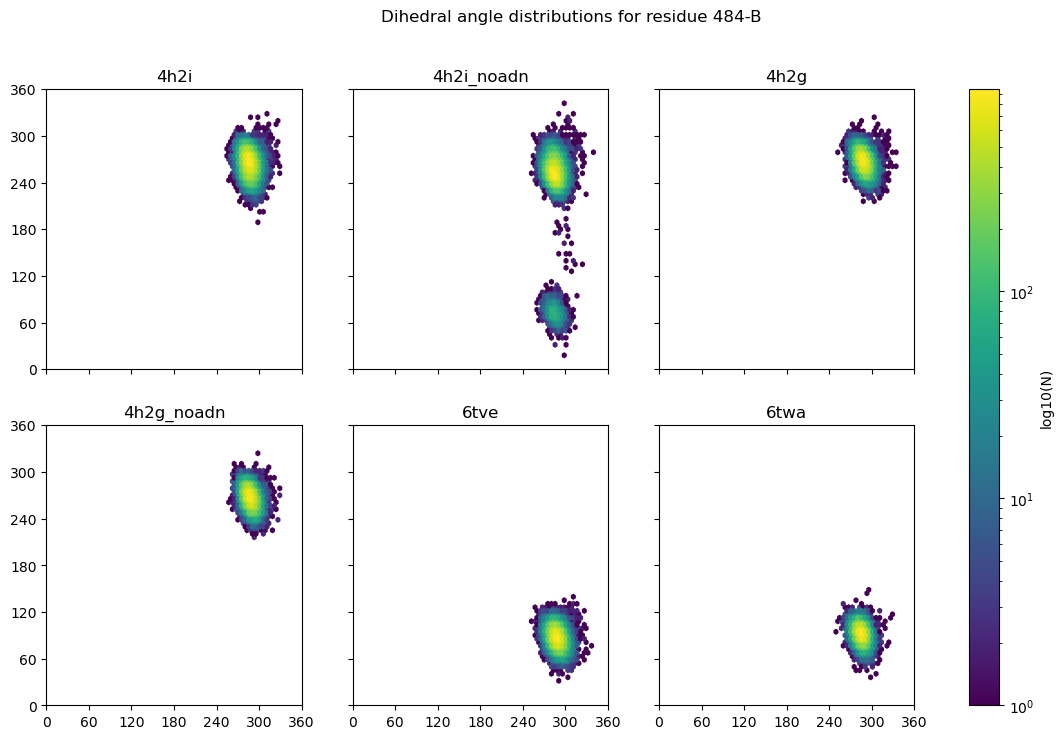

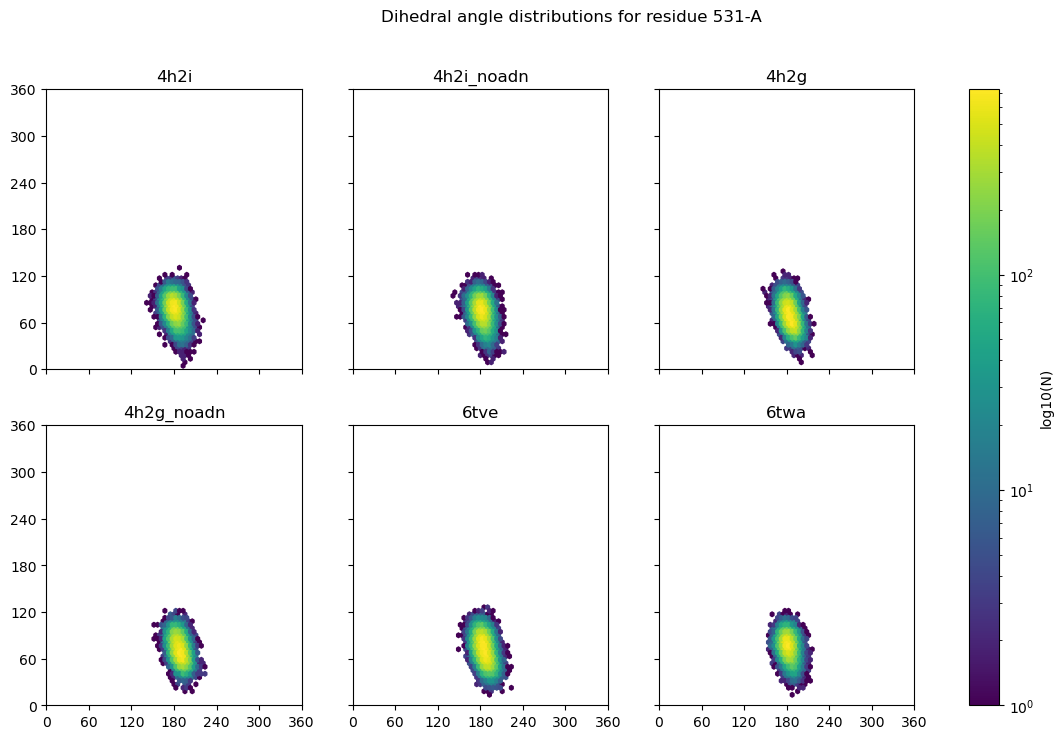

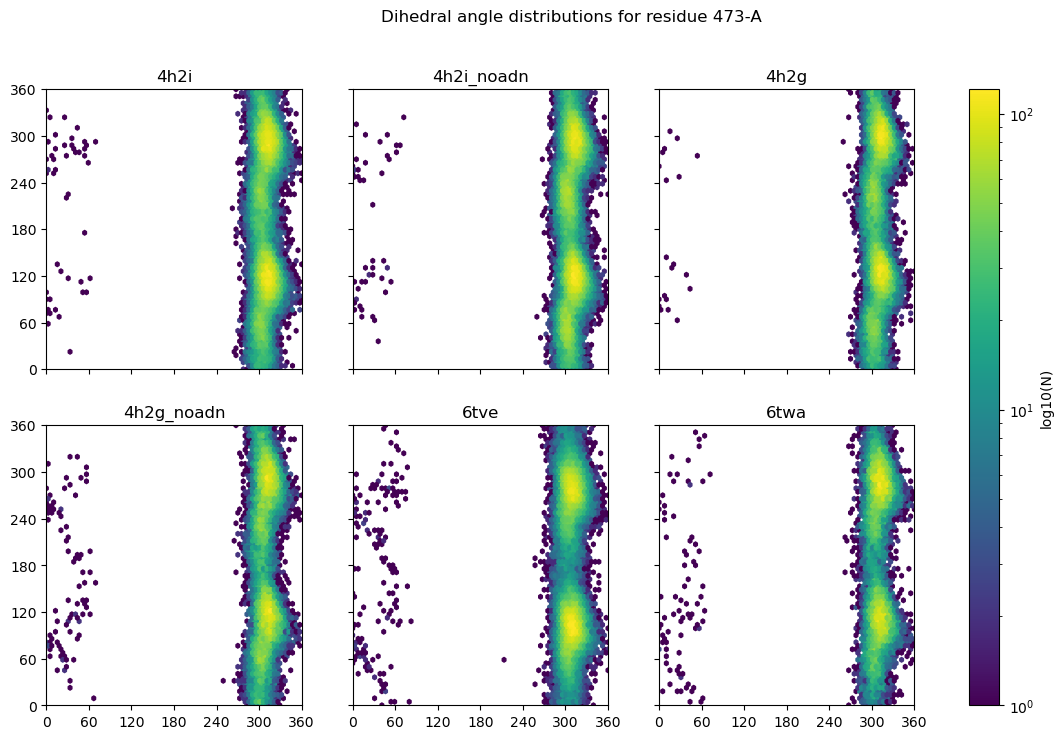

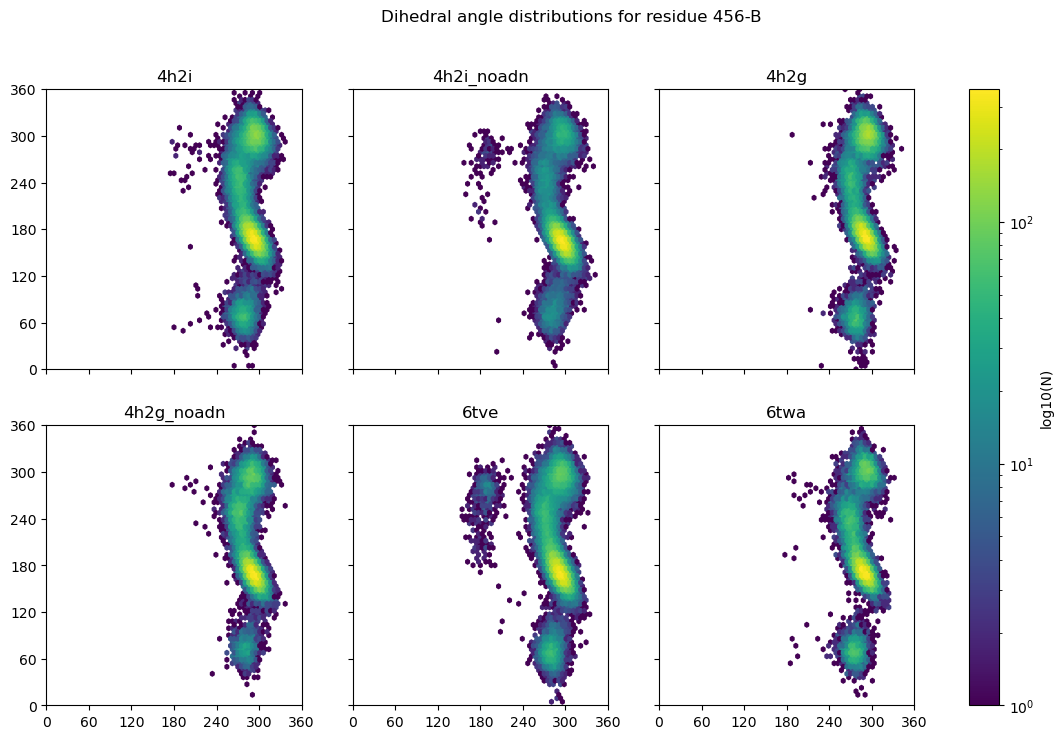

In [28]:
for residue in janin_results['4h2g'].keys():
    fig, axes = plt.subplots(
    2,
    3,
    sharex=True,
    sharey=True,
    figsize=(14,8)
    )

    axes = axes.flatten()

    for ax, name in zip(axes, janin_results.keys()):
    
        angles = janin_results[name][residue]
        chi1 = angles['chi1']
        chi2 = angles['chi2']

        hb = ax.hexbin(
            chi1,
            chi2,
            gridsize=70,
            bins='log',
            extent=(0,360,0,360)
        )

        ax.set_title(name)
        ax.set_xlim(0,360)
        ax.set_ylim(0,360)
        ax.set_xticks([0, 60, 120, 180, 240, 300, 360])
        ax.set_yticks([0, 60, 120, 180, 240, 300, 360])

    fig.colorbar(hb, ax=axes, label="log10(N)")
    fig.suptitle(f"Dihedral angle distributions for residue {residue}")  
    
    #plt.tight_layout()
    plt.show()

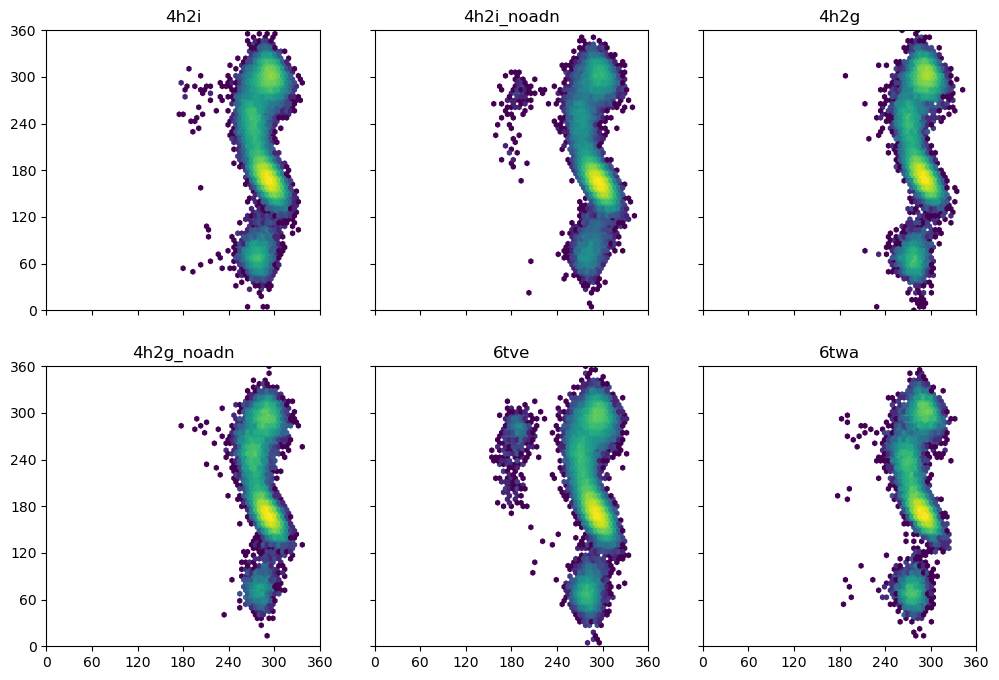

In [19]:
fig, axes = plt.subplots(
    2,
    3,
    sharex=True,
    sharey=True,
    figsize=(12,8)
)

axes = axes.flatten()

for ax, name in zip(axes, janin_results.keys()):
    
    angles = janin_results[name]['456-B']
    chi1 = angles['chi1']
    chi2 = angles['chi2']

    hb = ax.hexbin(
        chi1,
        chi2,
        gridsize=70,
        bins='log',
        extent=(0,360,0,360)
    )

    ax.set_title(name)
    ax.set_xlim(0,360)
    ax.set_ylim(0,360)
    ax.set_xticks([0, 60, 120, 180, 240, 300, 360])
    ax.set_yticks([0, 60, 120, 180, 240, 300, 360])


(0.0, 360.0)

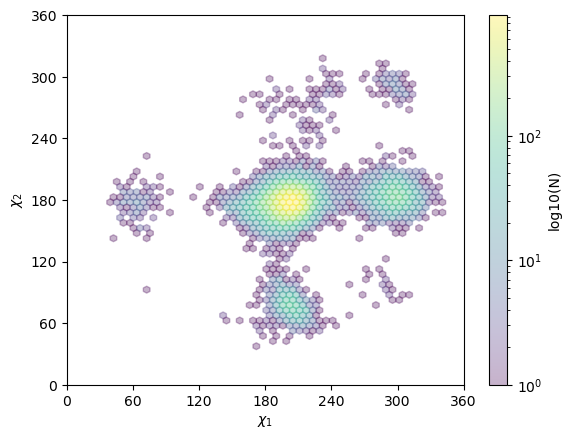

In [76]:
plt.hexbin(chi1, chi2, gridsize=50, bins="log", alpha=0.3)
plt.xlabel(r"$\chi_1$")
plt.ylabel(r"$\chi_2$")
plt.xlim(0, 360)
plt.xticks([0, 60, 120, 180, 240, 300, 360])
plt.yticks([0, 60, 120, 180, 240, 300, 360])
plt.colorbar(label='log10(N)')
plt.ylim(0, 360)

(0.0, 360.0)

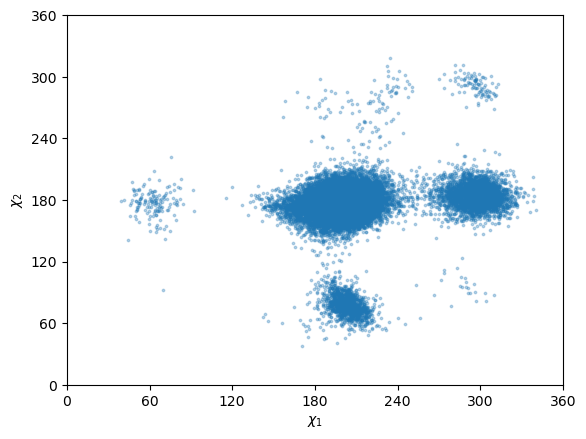

In [66]:
angles = janin_results['471-A'].angles[:, 0, :]
chi1 = angles[:, 0]
chi2 = angles[:, 1]

plt.scatter(chi1, chi2, s=3, alpha=0.3)
plt.xlabel(r"$\chi_1$")
plt.ylabel(r"$\chi_2$")
plt.xlim(0, 360)
plt.xticks([0, 60, 120, 180, 240, 300, 360])
plt.yticks([0, 60, 120, 180, 240, 300, 360])
plt.ylim(0, 360)


In [ ]:
test_angles = test_janin.results.angles[:, 0, :]
test_angles[:, 0] # chi 1
test_angles[:, 1] # chi 2

array([181.47941484, 174.44214346, 171.25434994, ..., 178.42216968,
       182.06659036, 178.31665594], shape=(30003,))

<Axes: xlabel='$\\chi_1$', ylabel='$\\chi_2$'>

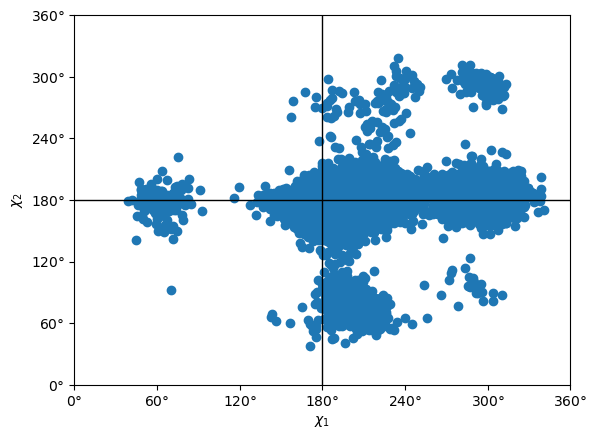

In [58]:
test_janin.plot()